# 🌾 Market Price Prediction using Machine Learning
### CSE23602 – Machine Learning | Course Project
**Global Academy of Technology, Bengaluru**

| Team Member | USN |
|---|---|
| Dhyan Kumar M | 1GA23CS040 |
| Abhishek M H | 1GA23CS004 |
| Divya Chatter | 1GA23CS042 |

**Faculty In-charge:** Reshma D'Souza

---

## 📋 Project Overview
This notebook implements a complete Machine Learning pipeline to **predict future agricultural commodity prices** using historical Indian Mandi (market) data (2023–2025). The system uses **Linear Regression**, **Random Forest**, and **Decision Tree** models to help farmers make informed selling decisions.

### Datasets Used
- [Dataset 1 – arunkumargiri](https://www.kaggle.com/datasets/arunkumargiri/indian-agricultural-mandi-prices-20232025)
- [Dataset 2 – arjunyadav99](https://www.kaggle.com/datasets/arjunyadav99/indian-agricultural-mandi-prices-20232025)

---
## ⚙️ Step 0: Install & Import Libraries

In [1]:
# Install any missing libraries
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['kagglehub', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'xgboost']:
    install(pkg)

print('✅ All libraries installed successfully!')

✅ All libraries installed successfully!


In [2]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import os, warnings
warnings.filterwarnings('ignore')

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})
PALETTE = 'Set2'

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, mean_absolute_percentage_error)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

print('✅ All libraries imported successfully!')
print(f'   XGBoost available: {XGB_AVAILABLE}')

✅ All libraries imported successfully!
   XGBoost available: True


---
## 📦 Step 1: Data Collection — Download Kaggle Datasets

> **Instructions:**  
> - **Option A (Kaggle API – Recommended):** Set your Kaggle credentials and run the cell below.  
> - **Option B (Manual):** Download CSV files from Kaggle and place them in the `data/` folder, then skip to Step 1b.

In [3]:
# ── Option A: Download using kagglehub (auto-uses ~/.kaggle/kaggle.json) ──────
# If you haven't configured Kaggle API yet:
#   1. Go to https://www.kaggle.com/settings → Create New Token
#   2. Place kaggle.json in ~/.kaggle/
#   3. Then run this cell

import kagglehub

DOWNLOAD = False   # ← Set to True if you want auto-download via Kaggle API

if DOWNLOAD:
    print('📥 Downloading Dataset 1 (arunkumargiri)...')
    path1 = kagglehub.dataset_download('arunkumargiri/indian-agricultural-mandi-prices-20232025')
    print(f'   Saved to: {path1}')

    print('📥 Downloading Dataset 2 (arjunyadav99)...')
    path2 = kagglehub.dataset_download('arjunyadav99/indian-agricultural-mandi-prices-20232025')
    print(f'   Saved to: {path2}')
else:
    print('ℹ️  Auto-download skipped. Using manual file paths below.')

ℹ️  Auto-download skipped. Using manual file paths below.


In [4]:
# ── Step 1b: Load Data ─────────────────────────────────────────────────────────
# Adjust file paths below to match where your CSV file(s) are saved.
# Common column names for Indian Mandi datasets:
#   State, District, Market, Commodity, Variety, Grade, Arrival_Date,
#   Min_x0020_Price, Max_x0020_Price, Modal_x0020_Price

# ── If you have the Kaggle path from above, use: ──────────────────────────────
# import glob
# csv_files = glob.glob(os.path.join(path1, '**/*.csv'), recursive=True)
# df1 = pd.read_csv(csv_files[0])

# ── Manual path (edit these) ───────────────────────────────────────────────────
DATA_PATH_1 = 'data/mandi_prices_dataset1.csv'   # ← arunkumargiri dataset
DATA_PATH_2 = 'data/mandi_prices_dataset2.csv'   # ← arjunyadav99 dataset

# Create data/ folder if not present
os.makedirs('data', exist_ok=True)

dfs = []
for path, label in [(DATA_PATH_1, 'Dataset-1'), (DATA_PATH_2, 'Dataset-2')]:
    if os.path.exists(path):
        tmp = pd.read_csv(path, encoding='utf-8', low_memory=False)
        tmp['source'] = label
        dfs.append(tmp)
        print(f'✅ Loaded {label}: {tmp.shape[0]:,} rows × {tmp.shape[1]} cols')
    else:
        print(f'⚠️  {label} not found at "{path}" — skipping.')

if dfs:
    df_raw = pd.concat(dfs, ignore_index=True)
    print(f'\n🔗 Combined shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} cols')
else:
    # ── DEMO FALLBACK: synthetic data so the whole notebook runs end-to-end ──
    print('\n⚠️  No CSV files found — generating synthetic demo data for testing.')
    np.random.seed(42)
    n = 12000
    dates = pd.date_range('2023-01-01', '2025-04-30', freq='D')
    states = ['Karnataka', 'Maharashtra', 'Punjab', 'Uttar Pradesh', 'Andhra Pradesh']
    commodities = ['Tomato', 'Onion', 'Potato', 'Wheat', 'Rice', 'Maize', 'Turmeric']
    varieties   = ['Local', 'Hybrid', 'Desi']

    df_raw = pd.DataFrame({
        'State'            : np.random.choice(states, n),
        'District'         : ['District_' + str(np.random.randint(1,20)) for _ in range(n)],
        'Market'           : ['Market_'   + str(np.random.randint(1,50)) for _ in range(n)],
        'Commodity'        : np.random.choice(commodities, n),
        'Variety'          : np.random.choice(varieties, n),
        'Grade'            : np.random.choice(['FAQ', 'A', 'B'], n),
        'Arrival_Date'     : np.random.choice(dates, n),
        'Min_Price'        : np.random.randint(500, 2000, n),
        'Max_Price'        : np.random.randint(2000, 5000, n),
        'Modal_Price'      : np.random.randint(1000, 4000, n),
        'source'           : 'Synthetic',
    })
    # Ensure Modal_Price is between Min and Max
    df_raw['Modal_Price'] = (
        df_raw['Min_Price'] +
        ((df_raw['Max_Price'] - df_raw['Min_Price']) * np.random.rand(n)).astype(int)
    )
    print(f'   Synthetic data created: {df_raw.shape}')

df_raw.head(3)

✅ Loaded Dataset-1: 811,131 rows × 11 cols
✅ Loaded Dataset-2: 737,392 rows × 11 cols

🔗 Combined shape: 1,548,523 rows × 11 cols


,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date,source
0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,NaN,NaN,NaN,6/6/2023,Dataset-1
1,Maharashtra,NaN,Patan,Tomato,Other,FAQ,1000.0,1500.0,NaN,6/6/2023,Dataset-1
2,uttar pradesh,mainpuri,NaN,Potato,NaN,NaN,800.0,820.0,NaN,6/6/2023,Dataset-1


---
## 🔍 Step 2: Exploratory Data Analysis (EDA)

In [5]:
# ── 2.1 Basic Info ─────────────────────────────────────────────────────────────
print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)
print(f'Shape         : {df_raw.shape}')
print(f'Memory usage  : {df_raw.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print()
print('Column dtypes:')
print(df_raw.dtypes)
print()
print('Statistical Summary:')
df_raw.describe(include='all').T

DATASET OVERVIEW
Shape         : (1548523, 11)
Memory usage  : 221.62 MB

Column dtypes:
STATE                str
District Name        str
Market Name          str
Commodity            str
Variety              str
Grade                str
Min_Price        float64
Max_Price        float64
Modal_Price      float64
Price Date           str
source               str
dtype: object

Statistical Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
STATE,1383718,118,Uttar Pradesh,315199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District Name,1345250,373,bulandshahar,19352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Market Name,1345192,1598,Pratapgarh,8074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Commodity,1345546,5,Potato,597563,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Variety,1346301,94,Other,412954,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Grade,1346015,7,FAQ,1172957,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Min_Price,1345876.0,NaN,NaN,NaN,2204.990415,1939.383804,0.0,1100.0,2000.0,2700.0,420000.0
Max_Price,1345331.0,NaN,NaN,NaN,2658.704466,2064.53511,0.0,1500.0,2300.0,3210.0,480000.0
Modal_Price,1345917.0,NaN,NaN,NaN,2475.83458,2031.557696,0.0,1300.0,2150.0,3000.0,460000.0
Price Date,1345449,737,6/19/2023,3445,NaN,NaN,NaN,NaN,NaN,NaN,NaN


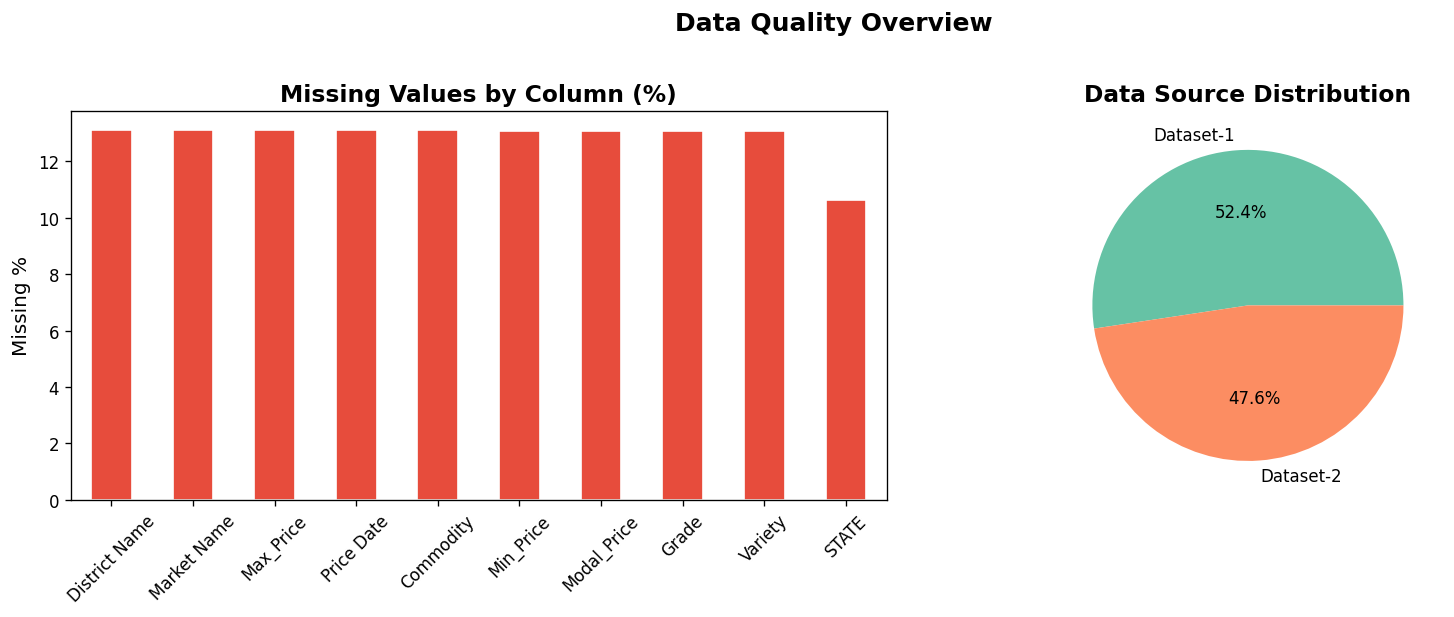

               Missing Count  Missing %
District Name         203273      13.13
Market Name           203331      13.13
Max_Price             203192      13.12
Price Date            203074      13.11
Commodity             202977      13.11
Min_Price             202647      13.09
Modal_Price           202606      13.08
Grade                 202508      13.08
Variety               202222      13.06
STATE                 164805      10.64


In [6]:
# ── 2.2 Missing Values Heatmap ─────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
miss_df = miss_df[miss_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(miss_df) > 0:
    miss_df['Missing %'].plot(kind='bar', ax=axes[0], color='#e74c3c', edgecolor='white')
    axes[0].set_title('Missing Values by Column (%)', fontweight='bold')
    axes[0].set_ylabel('Missing %')
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].text(0.5, 0.5, '✅ No Missing Values!', ha='center', va='center',
                 fontsize=16, transform=axes[0].transAxes, color='green')
    axes[0].set_title('Missing Values', fontweight='bold')

# Dataset source distribution
if 'source' in df_raw.columns:
    df_raw['source'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                          colors=sns.color_palette(PALETTE))
    axes[1].set_title('Data Source Distribution', fontweight='bold')
    axes[1].set_ylabel('')

plt.suptitle('Data Quality Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_01_missing_values.png', bbox_inches='tight')
plt.show()
print(miss_df)

In [7]:
# ── 2.3 Identify Price Column ──────────────────────────────────────────────────
# Auto-detect modal/modal price column (handles different naming conventions)
MODAL_COL = None
MIN_COL   = None
MAX_COL   = None
DATE_COL  = None

col_lower = {c.lower().replace(' ', '_').replace('x0020_', ''): c for c in df_raw.columns}

for key, col in col_lower.items():
    if 'modal' in key and 'price' in key: MODAL_COL = col
    if 'min'   in key and 'price' in key: MIN_COL   = col
    if 'max'   in key and 'price' in key: MAX_COL   = col
    if 'date'  in key or 'arrival' in key: DATE_COL = col

# Fallback
if MODAL_COL is None: MODAL_COL = [c for c in df_raw.columns if 'Modal' in c or 'modal' in c][0] if any('odal' in c for c in df_raw.columns) else df_raw.select_dtypes('number').columns[-1]
if DATE_COL  is None: DATE_COL  = [c for c in df_raw.columns if 'Date' in c or 'date' in c][0] if any('ate' in c for c in df_raw.columns) else None

print(f'🎯 Target (price) column : {MODAL_COL}')
print(f'📅 Date column           : {DATE_COL}')
print(f'📉 Min price column      : {MIN_COL}')
print(f'📈 Max price column      : {MAX_COL}')

🎯 Target (price) column : Modal_Price
📅 Date column           : Price Date
📉 Min price column      : Min_Price
📈 Max price column      : Max_Price


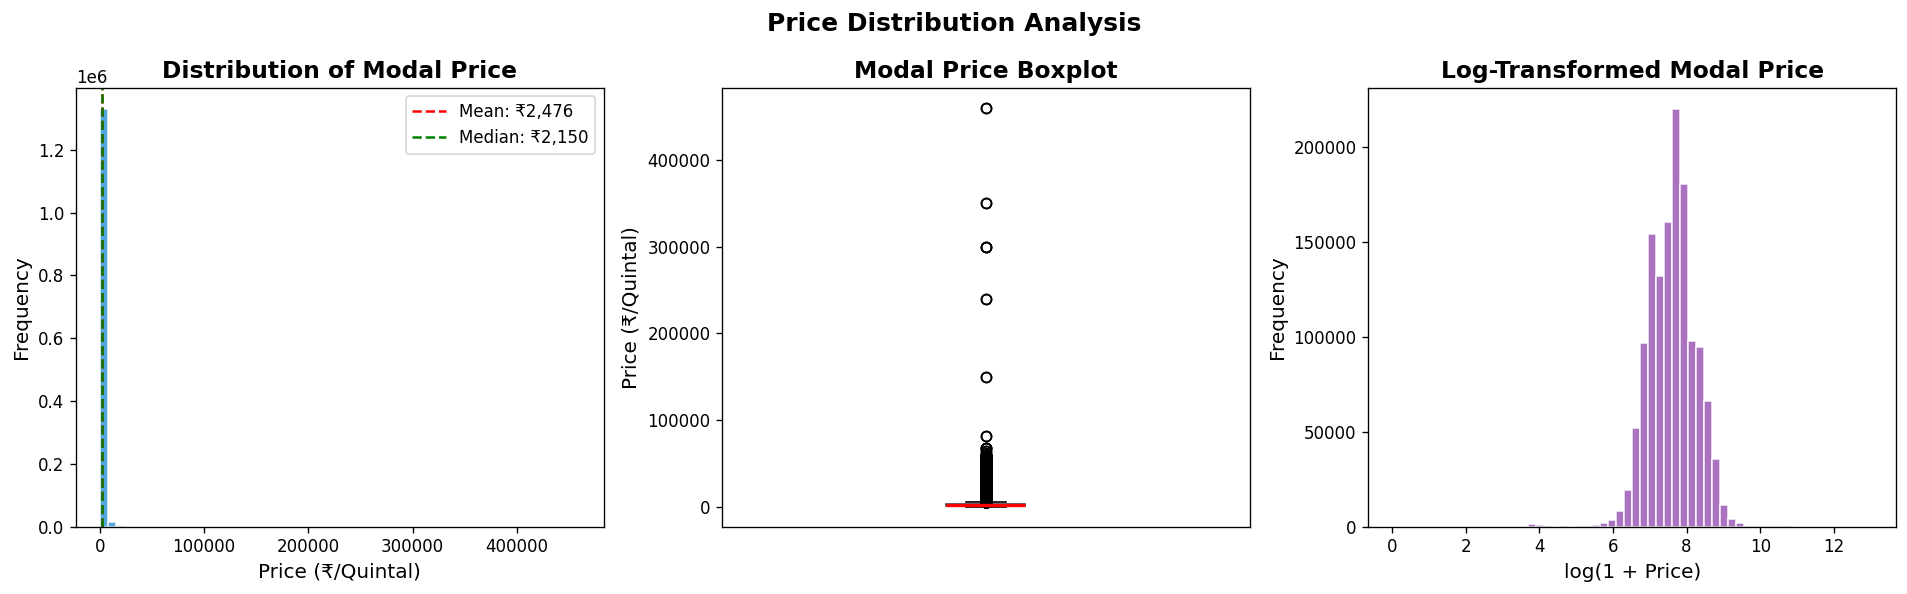


📊 Price Statistics (₹/Quintal):
count    ₹1,345,917.00
mean         ₹2,475.83
std          ₹2,031.56
min              ₹0.00
25%          ₹1,300.00
50%          ₹2,150.00
75%          ₹3,000.00
max        ₹460,000.00
Name: Modal_Price, dtype: str


In [8]:
# ── 2.4 Price Distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

price_data = df_raw[MODAL_COL].dropna()

# Histogram
axes[0].hist(price_data, bins=60, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].set_title(f'Distribution of Modal Price', fontweight='bold')
axes[0].set_xlabel('Price (₹/Quintal)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(price_data.mean(), color='red', linestyle='--', label=f'Mean: ₹{price_data.mean():,.0f}')
axes[0].axvline(price_data.median(), color='green', linestyle='--', label=f'Median: ₹{price_data.median():,.0f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(price_data, patch_artist=True,
                boxprops=dict(facecolor='#2ecc71', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Modal Price Boxplot', fontweight='bold')
axes[1].set_ylabel('Price (₹/Quintal)')
axes[1].set_xticks([])

# Log-scale distribution
log_data = np.log1p(price_data)
axes[2].hist(log_data, bins=60, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[2].set_title('Log-Transformed Modal Price', fontweight='bold')
axes[2].set_xlabel('log(1 + Price)')
axes[2].set_ylabel('Frequency')

plt.suptitle('Price Distribution Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_02_price_distribution.png', bbox_inches='tight')
plt.show()

print(f'\n📊 Price Statistics (₹/Quintal):')
print(price_data.describe().apply(lambda x: f'₹{x:,.2f}'))

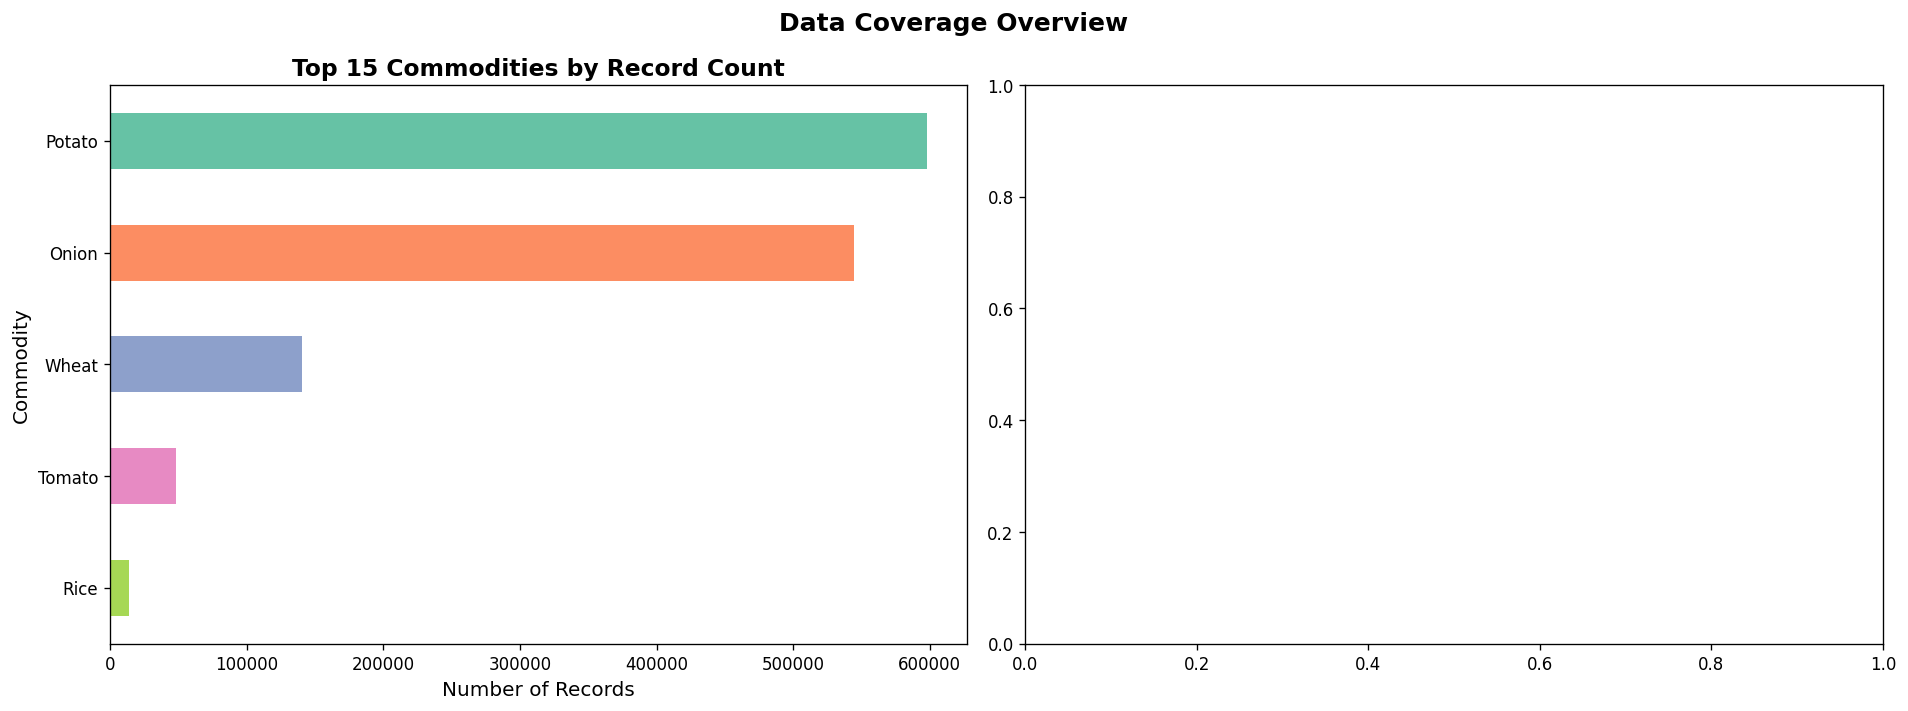

In [9]:
# ── 2.5 Top Commodities ────────────────────────────────────────────────────────
COMMODITY_COL = [c for c in df_raw.columns if 'ommodit' in c][0] if any('ommodit' in c for c in df_raw.columns) else None
STATE_COL     = [c for c in df_raw.columns if 'tate' in c][0] if any('tate' in c for c in df_raw.columns) else None

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if COMMODITY_COL:
    top_commodities = df_raw[COMMODITY_COL].value_counts().head(15)
    top_commodities.plot(kind='barh', ax=axes[0],
                         color=sns.color_palette('Set2', len(top_commodities)))
    axes[0].set_title('Top 15 Commodities by Record Count', fontweight='bold')
    axes[0].set_xlabel('Number of Records')
    axes[0].invert_yaxis()

if STATE_COL:
    top_states = df_raw[STATE_COL].value_counts().head(10)
    top_states.plot(kind='bar', ax=axes[1],
                    color=sns.color_palette('Set3', len(top_states)), edgecolor='white')
    axes[1].set_title('Top 10 States by Record Count', fontweight='bold')
    axes[1].set_ylabel('Number of Records')
    axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Data Coverage Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_03_commodity_state_distribution.png', bbox_inches='tight')
plt.show()

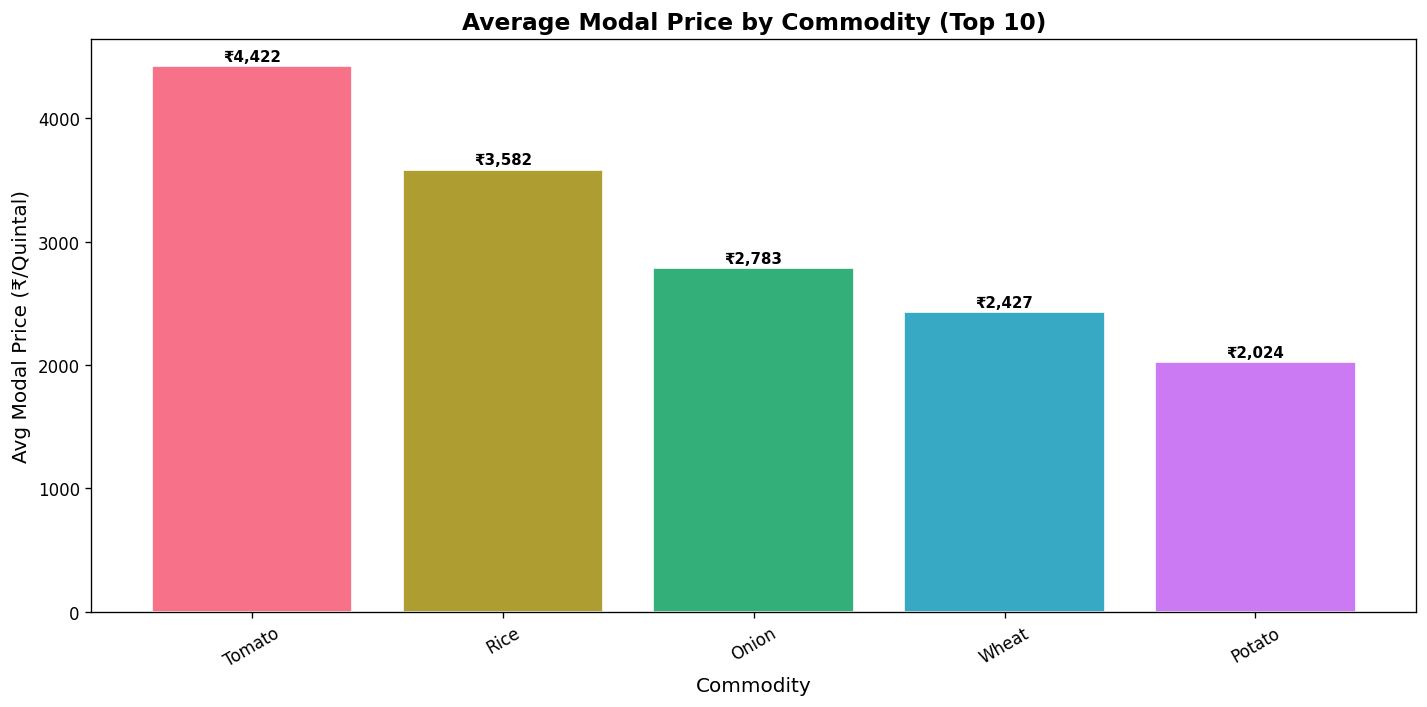

In [10]:
# ── 2.6 Average Price by Commodity (top 10) ────────────────────────────────────
if COMMODITY_COL:
    avg_price = (df_raw.groupby(COMMODITY_COL)[MODAL_COL]
                       .mean()
                       .sort_values(ascending=False)
                       .head(10))

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(avg_price.index, avg_price.values,
                  color=sns.color_palette('husl', len(avg_price)), edgecolor='white')

    for bar, val in zip(bars, avg_price.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'₹{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title('Average Modal Price by Commodity (Top 10)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Commodity')
    ax.set_ylabel('Avg Modal Price (₹/Quintal)')
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig('plot_04_avg_price_by_commodity.png', bbox_inches='tight')
    plt.show()

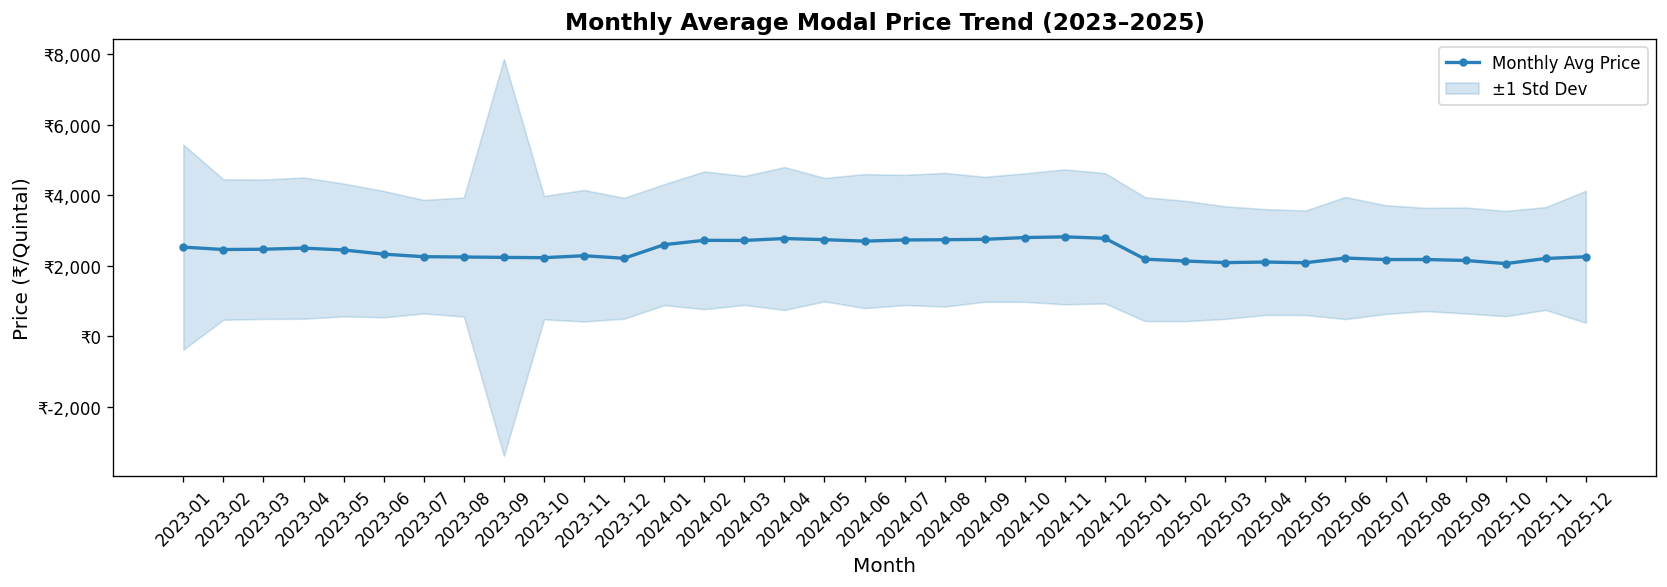

📅 Date range in dataset: 2023-01-07 00:00:00 → 2025-12-05 00:00:00


In [11]:
# ── 2.7 Price Trend Over Time ───────────────────────────────────────────────────
if DATE_COL:
    df_raw[DATE_COL] = pd.to_datetime(df_raw[DATE_COL], dayfirst=True, errors='coerce')
    df_raw = df_raw.dropna(subset=[DATE_COL])

    monthly = df_raw.groupby(df_raw[DATE_COL].dt.to_period('M'))[MODAL_COL].agg(['mean', 'std'])
    monthly.index = monthly.index.astype(str)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(monthly.index, monthly['mean'], color='#2980b9', linewidth=2, marker='o',
            markersize=4, label='Monthly Avg Price')
    ax.fill_between(monthly.index,
                    monthly['mean'] - monthly['std'],
                    monthly['mean'] + monthly['std'],
                    alpha=0.2, color='#2980b9', label='±1 Std Dev')
    ax.set_title('Monthly Average Modal Price Trend (2023–2025)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Price (₹/Quintal)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
    plt.tight_layout()
    plt.savefig('plot_05_price_trend.png', bbox_inches='tight')
    plt.show()

print('📅 Date range in dataset:', df_raw[DATE_COL].min() if DATE_COL else 'N/A',
      '→', df_raw[DATE_COL].max() if DATE_COL else 'N/A')

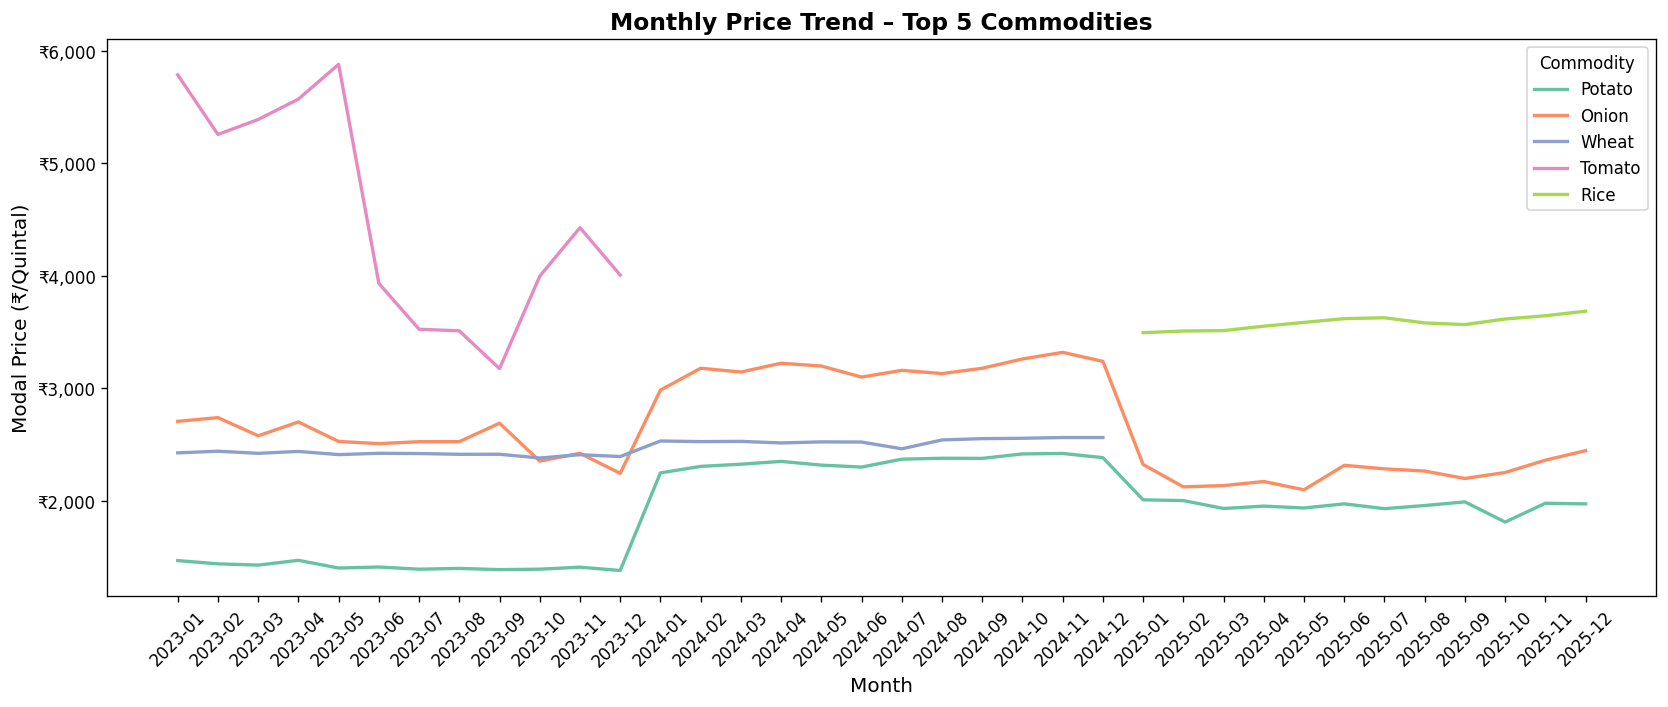

In [12]:
# ── 2.8 Commodity-wise Price Trend (Top 5) ──────────────────────────────────────
if DATE_COL and COMMODITY_COL:
    top5 = df_raw[COMMODITY_COL].value_counts().head(5).index.tolist()

    fig, ax = plt.subplots(figsize=(14, 6))
    colors = sns.color_palette(PALETTE, len(top5))

    for comm, color in zip(top5, colors):
        sub = df_raw[df_raw[COMMODITY_COL] == comm].copy()
        monthly_comm = sub.groupby(sub[DATE_COL].dt.to_period('M'))[MODAL_COL].mean()
        monthly_comm.index = monthly_comm.index.astype(str)
        ax.plot(monthly_comm.index, monthly_comm.values, label=comm, color=color, linewidth=2)

    ax.set_title('Monthly Price Trend – Top 5 Commodities', fontsize=14, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Modal Price (₹/Quintal)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Commodity')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
    plt.tight_layout()
    plt.savefig('plot_06_commodity_trend.png', bbox_inches='tight')
    plt.show()

---
## 🧹 Step 3: Data Preprocessing

In [13]:
# ── 3.1 Copy & Clean ────────────────────────────────────────────────────────────
df = df_raw.copy()

print('Before cleaning:', df.shape)

# Remove duplicate rows
n_dup = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f'  Dropped {n_dup:,} duplicate rows')

# Remove rows with missing target
n_before = len(df)
df.dropna(subset=[MODAL_COL], inplace=True)
print(f'  Dropped {n_before - len(df):,} rows with missing target ({MODAL_COL})')

# Remove outliers using IQR (3×) on price columns
for col in [c for c in [MODAL_COL, MIN_COL, MAX_COL] if c]:
    if col in df.columns:
        Q1, Q3 = df[col].quantile([0.01, 0.99])
        IQR    = Q3 - Q1
        mask   = (df[col] >= Q1 - 3*IQR) & (df[col] <= Q3 + 3*IQR)
        removed = (~mask).sum()
        df     = df[mask]
        print(f'  Removed {removed:,} extreme outliers from {col}')

print('After cleaning:', df.shape)

Before cleaning: (542124, 11)
  Dropped 171 duplicate rows
  Dropped 61,193 rows with missing target (Modal_Price)
  Removed 160 extreme outliers from Modal_Price
  Removed 45,640 extreme outliers from Min_Price
  Removed 34,541 extreme outliers from Max_Price
After cleaning: (400419, 11)


In [14]:
# ── 3.2 Feature Engineering ────────────────────────────────────────────────────
if DATE_COL and DATE_COL in df.columns:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')
    df['Year']    = df[DATE_COL].dt.year
    df['Month']   = df[DATE_COL].dt.month
    df['Day']     = df[DATE_COL].dt.day
    df['DayOfWeek'] = df[DATE_COL].dt.dayofweek
    df['Quarter'] = df[DATE_COL].dt.quarter
    df['WeekOfYear'] = df[DATE_COL].dt.isocalendar().week.astype(int)

    # Seasonal flag: Kharif (Jun–Nov) / Rabi (Dec–May)
    df['Season'] = df['Month'].apply(lambda m: 'Kharif' if 6 <= m <= 11 else 'Rabi')

    # Price spread
    if MIN_COL and MAX_COL and MIN_COL in df.columns and MAX_COL in df.columns:
        df['Price_Spread'] = df[MAX_COL] - df[MIN_COL]
        df['Price_Ratio']  = df[MODAL_COL] / df[MIN_COL].replace(0, np.nan)

    print('✅ Date features created: Year, Month, Day, DayOfWeek, Quarter, WeekOfYear, Season')

# Lag features (rolling average per commodity)
if COMMODITY_COL and DATE_COL:
    df = df.sort_values(DATE_COL)
    df['Price_Lag1M'] = (
        df.groupby(COMMODITY_COL)[MODAL_COL]
          .transform(lambda x: x.shift(30).rolling(30, min_periods=1).mean())
    )
    df['Price_RollMean7'] = (
        df.groupby(COMMODITY_COL)[MODAL_COL]
          .transform(lambda x: x.rolling(7, min_periods=1).mean())
    )
    print('✅ Lag features created: Price_Lag1M, Price_RollMean7')

df.head(3)

✅ Date features created: Year, Month, Day, DayOfWeek, Quarter, WeekOfYear, Season
✅ Lag features created: Price_Lag1M, Price_RollMean7


,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date,...,Month,Day,DayOfWeek,Quarter,WeekOfYear,Season,Price_Spread,Price_Ratio,Price_Lag1M,Price_RollMean7
42821,Uttar Pradesh,jhansi,Moth,NaN,Dara,FAQ,2130.0,2200.0,2180.0,2023-01-07,...,1,7,5,1,1,Rabi,70.0,1.023474,NaN,NaN
853286,Haryana,panipat,Samalkha,Onion,Local,FAQ,1200.0,1200.0,1200.0,2023-01-07,...,1,7,5,1,1,Rabi,0.0,1.000000,NaN,1200.0
853287,Rajasthan,alwar,Alwar (F&V),Onion,Other,FAQ,1000.0,1400.0,1200.0,2023-01-07,...,1,7,5,1,1,Rabi,400.0,1.200000,NaN,1200.0


In [15]:
# ── 3.3 Label Encoding for Categorical Features ────────────────────────────────
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
# Exclude date and source columns
cat_cols = [c for c in cat_cols if c not in [DATE_COL, 'source']]

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f'  Encoded: {col} → {col}_enc  ({le.classes_[:5]}...)')

print('\n✅ Label encoding complete')

  Encoded: STATE → STATE_enc  (['  Punjab ' '  punjab ' ' Andhra Pradesh ' ' Assam ' ' Bihar ']...)
  Encoded: District Name → District Name_enc  (['adilabad' 'agra' 'ahmedabad' 'ahmednagar' 'ajmer']...)
  Encoded: Market Name → Market Name_enc  (['A lot' 'AJattihalli(Uzhavar Sandhai )' 'Aarah' 'Abohar' 'Abu Road']...)
  Encoded: Commodity → Commodity_enc  (['Onion' 'Potato' 'Rice' 'Tomato' 'Wheat']...)
  Encoded: Variety → Variety_enc  (['(Red Nanital)' '1009 Kar' '147 Average' '147 Best' '1482']...)
  Encoded: Grade → Grade_enc  (['FAQ' 'Large' 'Local' 'Medium' 'Non-FAQ']...)
  Encoded: Season → Season_enc  (['Kharif' 'Rabi']...)

✅ Label encoding complete


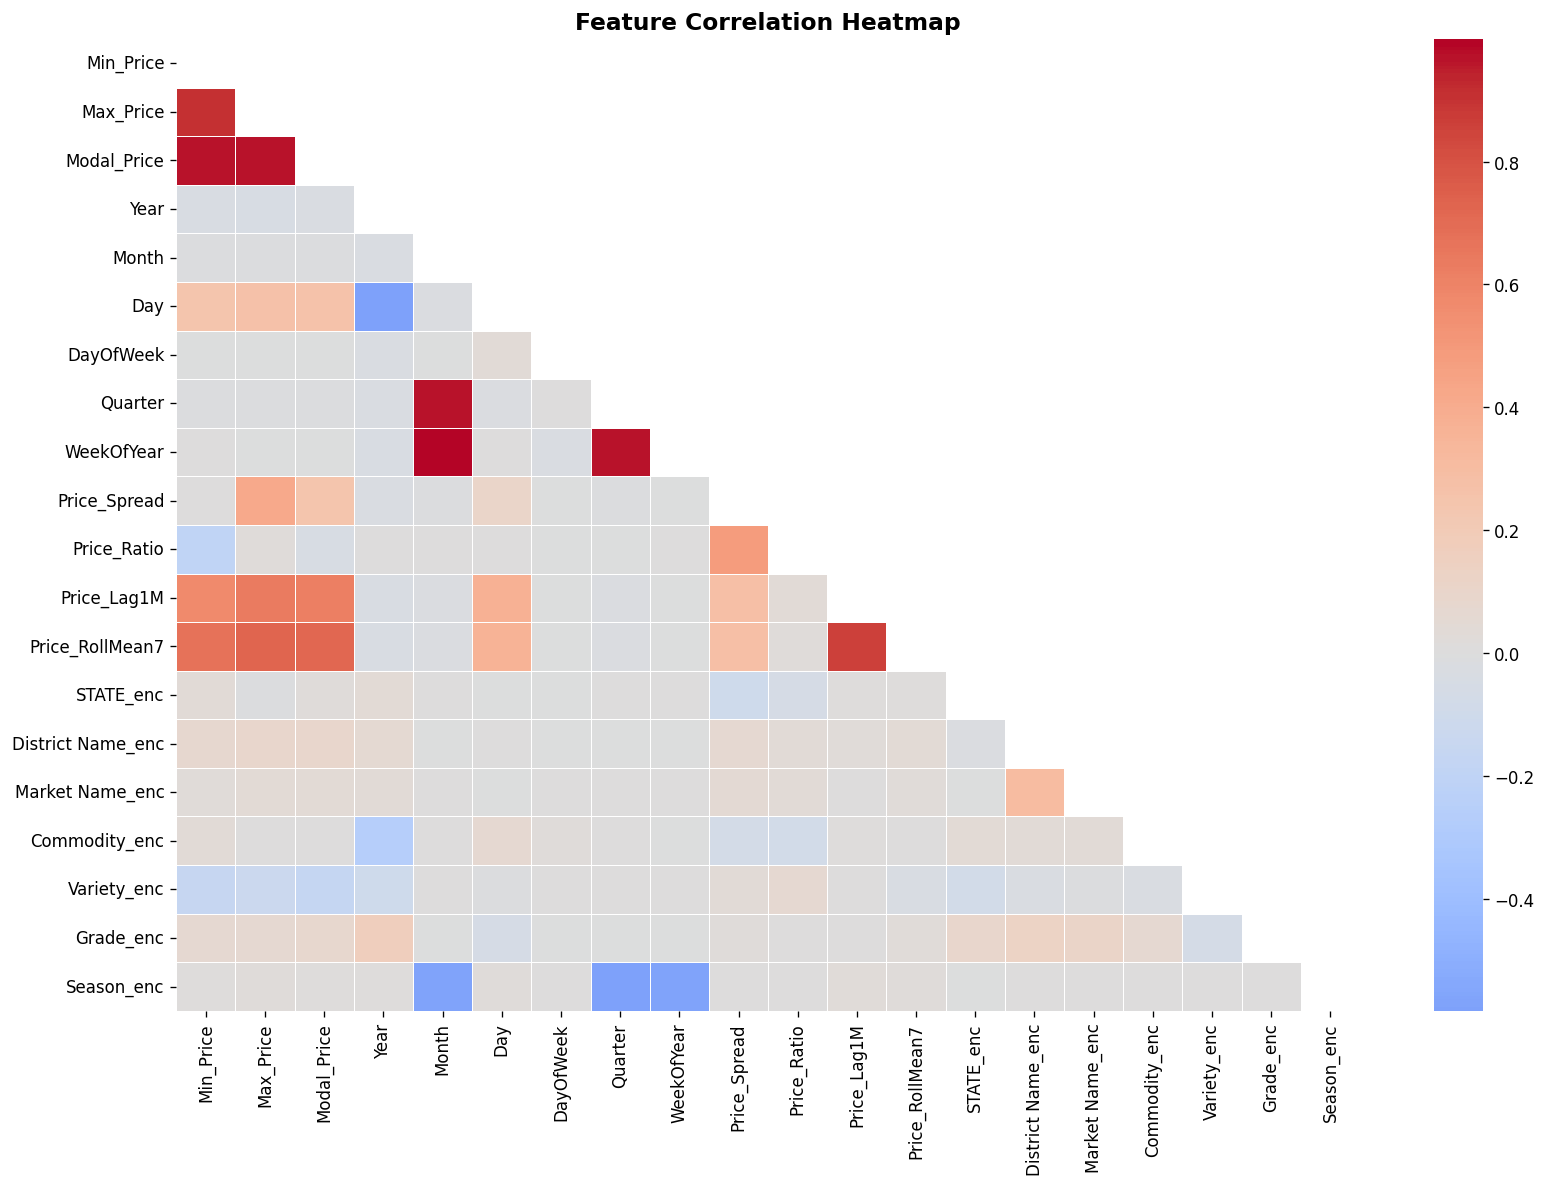


Top correlations with Modal_Price:
Max_Price             0.9734
Min_Price             0.9629
Price_RollMean7       0.7185
Price_Lag1M           0.6187
Day                   0.2579
Price_Spread          0.2394
Variety_enc          -0.1634
District Name_enc     0.0966
Grade_enc             0.0827
Price_Ratio          -0.0439
Name: Modal_Price, dtype: str


In [16]:
# ── 3.4 Correlation Heatmap ────────────────────────────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, fmt='.2f')
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_07_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Top correlations with target
corr_target = corr_matrix[MODAL_COL].drop(MODAL_COL).sort_values(key=abs, ascending=False)
print(f'\nTop correlations with {MODAL_COL}:')
print(corr_target.head(10).apply(lambda x: f'{x:.4f}'))

---
## 🎯 Step 4: Feature Selection & Dataset Preparation

In [17]:
# ── 4.1 Select Feature Columns ─────────────────────────────────────────────────
# Use encoded categoricals + numeric time/price features
encoded_cats = [c for c in df.columns if c.endswith('_enc')]
time_feats   = [c for c in ['Year','Month','Day','DayOfWeek','Quarter','WeekOfYear'] if c in df.columns]
price_feats  = [c for c in [MIN_COL, MAX_COL, 'Price_Spread','Price_Ratio',
                             'Price_Lag1M','Price_RollMean7'] if c and c in df.columns]

FEATURES = encoded_cats + time_feats + price_feats
TARGET   = MODAL_COL

print('Features selected:')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:2d}. {f}')
print(f'\nTarget: {TARGET}')
print(f'Total features: {len(FEATURES)}')

Features selected:
   1. STATE_enc
   2. District Name_enc
   3. Market Name_enc
   4. Commodity_enc
   5. Variety_enc
   6. Grade_enc
   7. Season_enc
   8. Year
   9. Month
  10. Day
  11. DayOfWeek
  12. Quarter
  13. WeekOfYear
  14. Min_Price
  15. Max_Price
  16. Price_Spread
  17. Price_Ratio
  18. Price_Lag1M
  19. Price_RollMean7

Target: Modal_Price
Total features: 19


Total samples  : 374,257
Training set   : 299,405 (80.0%)
Test set       : 74,852 (20.0%)

✅ Train/test split and scaling done!


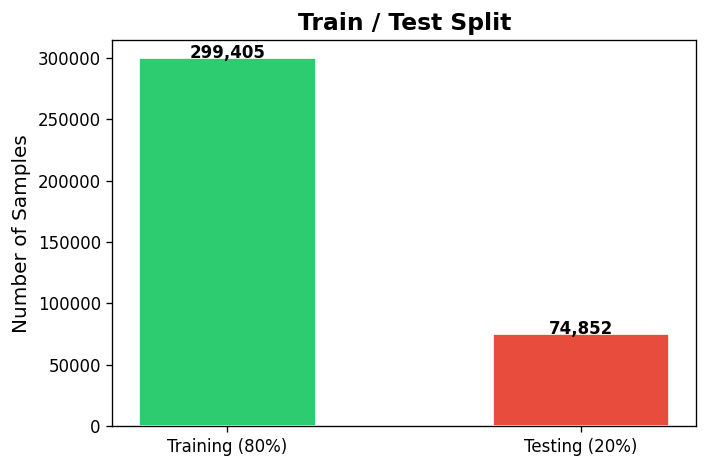

In [18]:
# ── 4.2 Train / Test Split ─────────────────────────────────────────────────────
df_model = df[FEATURES + [TARGET]].dropna()

X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Total samples  : {len(df_model):,}')
print(f'Training set   : {len(X_train):,} ({len(X_train)/len(df_model)*100:.1f}%)')
print(f'Test set       : {len(X_test):,} ({len(X_test)/len(df_model)*100:.1f}%)')

# Feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('\n✅ Train/test split and scaling done!')

# Visualise split
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Training (80%)', 'Testing (20%)'], [len(X_train), len(X_test)],
       color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
ax.set_title('Train / Test Split', fontweight='bold')
ax.set_ylabel('Number of Samples')
for bar, val in zip(ax.patches, [len(X_train), len(X_test)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_08_train_test_split.png', bbox_inches='tight')
plt.show()

---
## 🤖 Step 5: Model Building & Training

In [19]:
# ── 5.1 Define Models ──────────────────────────────────────────────────────────
models = {
    '📐 Linear Regression'       : LinearRegression(),
    '🔱 Ridge Regression'        : Ridge(alpha=1.0),
    '🌳 Decision Tree'           : DecisionTreeRegressor(max_depth=10, random_state=42),
    '🌲 Random Forest'           : RandomForestRegressor(n_estimators=100, max_depth=15,
                                                         random_state=42, n_jobs=-1),
    '🚀 Gradient Boosting'       : GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                                              max_depth=5, random_state=42),
}

if XGB_AVAILABLE:
    models['⚡ XGBoost'] = XGBRegressor(n_estimators=200, learning_rate=0.05,
                                        max_depth=6, random_state=42,
                                        tree_method='hist', verbosity=0)

print(f'✅ {len(models)} models configured:')
for name in models:
    print(f'   {name}')

✅ 6 models configured:
   📐 Linear Regression
   🔱 Ridge Regression
   🌳 Decision Tree
   🌲 Random Forest
   🚀 Gradient Boosting
   ⚡ XGBoost


In [20]:
# ── 5.2 Train All Models & Collect Metrics ────────────────────────────────────
results = {}

def evaluate(model, X_tr, y_tr, X_te, y_te, scaled=False):
    """Train a model and return all metrics."""
    Xtr = X_tr if scaled else X_train
    Xte = X_te if scaled else X_test
    model.fit(Xtr, y_tr)
    preds = model.predict(Xte)

    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mape = mean_absolute_percentage_error(y_te, preds) * 100
    r2   = r2_score(y_te, preds)
    acc  = max(0, (1 - mape/100)) * 100   # Accuracy proxy

    return {'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape,
            'R²': r2, 'Accuracy (%)': acc, 'Predictions': preds}

for name, model in models.items():
    print(f'⏳ Training {name}...')
    use_scaled = 'Linear' in name or 'Ridge' in name
    res = evaluate(model, X_train_sc, y_train, X_test_sc, y_test, scaled=True) \
          if use_scaled else \
          evaluate(model, X_train, y_train, X_test, y_test, scaled=False)
    results[name] = res
    print(f'   MAE={res["MAE"]:,.2f}  RMSE={res["RMSE"]:,.2f}  R²={res["R²"]:.4f}  Acc≈{res["Accuracy (%)"]:.2f}%')

print('\n✅ All models trained!')

⏳ Training 📐 Linear Regression...
   MAE=92.62  RMSE=212.03  R²=0.9829  Acc≈94.96%
⏳ Training 🔱 Ridge Regression...
   MAE=92.62  RMSE=212.03  R²=0.9829  Acc≈94.96%
⏳ Training 🌳 Decision Tree...
   MAE=46.49  RMSE=137.47  R²=0.9928  Acc≈97.30%
⏳ Training 🌲 Random Forest...
   MAE=9.41  RMSE=63.59  R²=0.9985  Acc≈99.50%
⏳ Training 🚀 Gradient Boosting...
   MAE=31.56  RMSE=60.38  R²=0.9986  Acc≈98.22%
⏳ Training ⚡ XGBoost...
   MAE=29.75  RMSE=108.98  R²=0.9955  Acc≈98.54%

✅ All models trained!


---
## 📊 Step 6: Model Evaluation & Comparison

In [21]:
# ── 6.1 Results Table ─────────────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    name: {k: v for k, v in res.items() if k != 'Predictions'}
    for name, res in results.items()
}).T.round(4)

metrics_df['MAE']         = metrics_df['MAE'].map('₹{:,.2f}'.format)
metrics_df['RMSE']        = metrics_df['RMSE'].map('₹{:,.2f}'.format)
metrics_df['MAPE (%)']    = metrics_df['MAPE (%)'].map('{:.2f}%'.format)
metrics_df['R²']          = metrics_df['R²'].map('{:.4f}'.format)
metrics_df['Accuracy (%)']= metrics_df['Accuracy (%)'].map('{:.2f}%'.format)

print('=' * 80)
print('                     MODEL PERFORMANCE COMPARISON')
print('=' * 80)
print(metrics_df.to_string())
print('=' * 80)

                     MODEL PERFORMANCE COMPARISON
                        MAE     RMSE MAPE (%)      R² Accuracy (%)
📐 Linear Regression  ₹92.62  ₹212.03    5.04%  0.9829       94.96%
🔱 Ridge Regression   ₹92.62  ₹212.03    5.04%  0.9829       94.96%
🌳 Decision Tree      ₹46.49  ₹137.47    2.70%  0.9928       97.30%
🌲 Random Forest       ₹9.41   ₹63.59    0.50%  0.9985       99.50%
🚀 Gradient Boosting  ₹31.56   ₹60.38    1.78%  0.9986       98.22%
⚡ XGBoost            ₹29.75  ₹108.98    1.46%  0.9955       98.54%


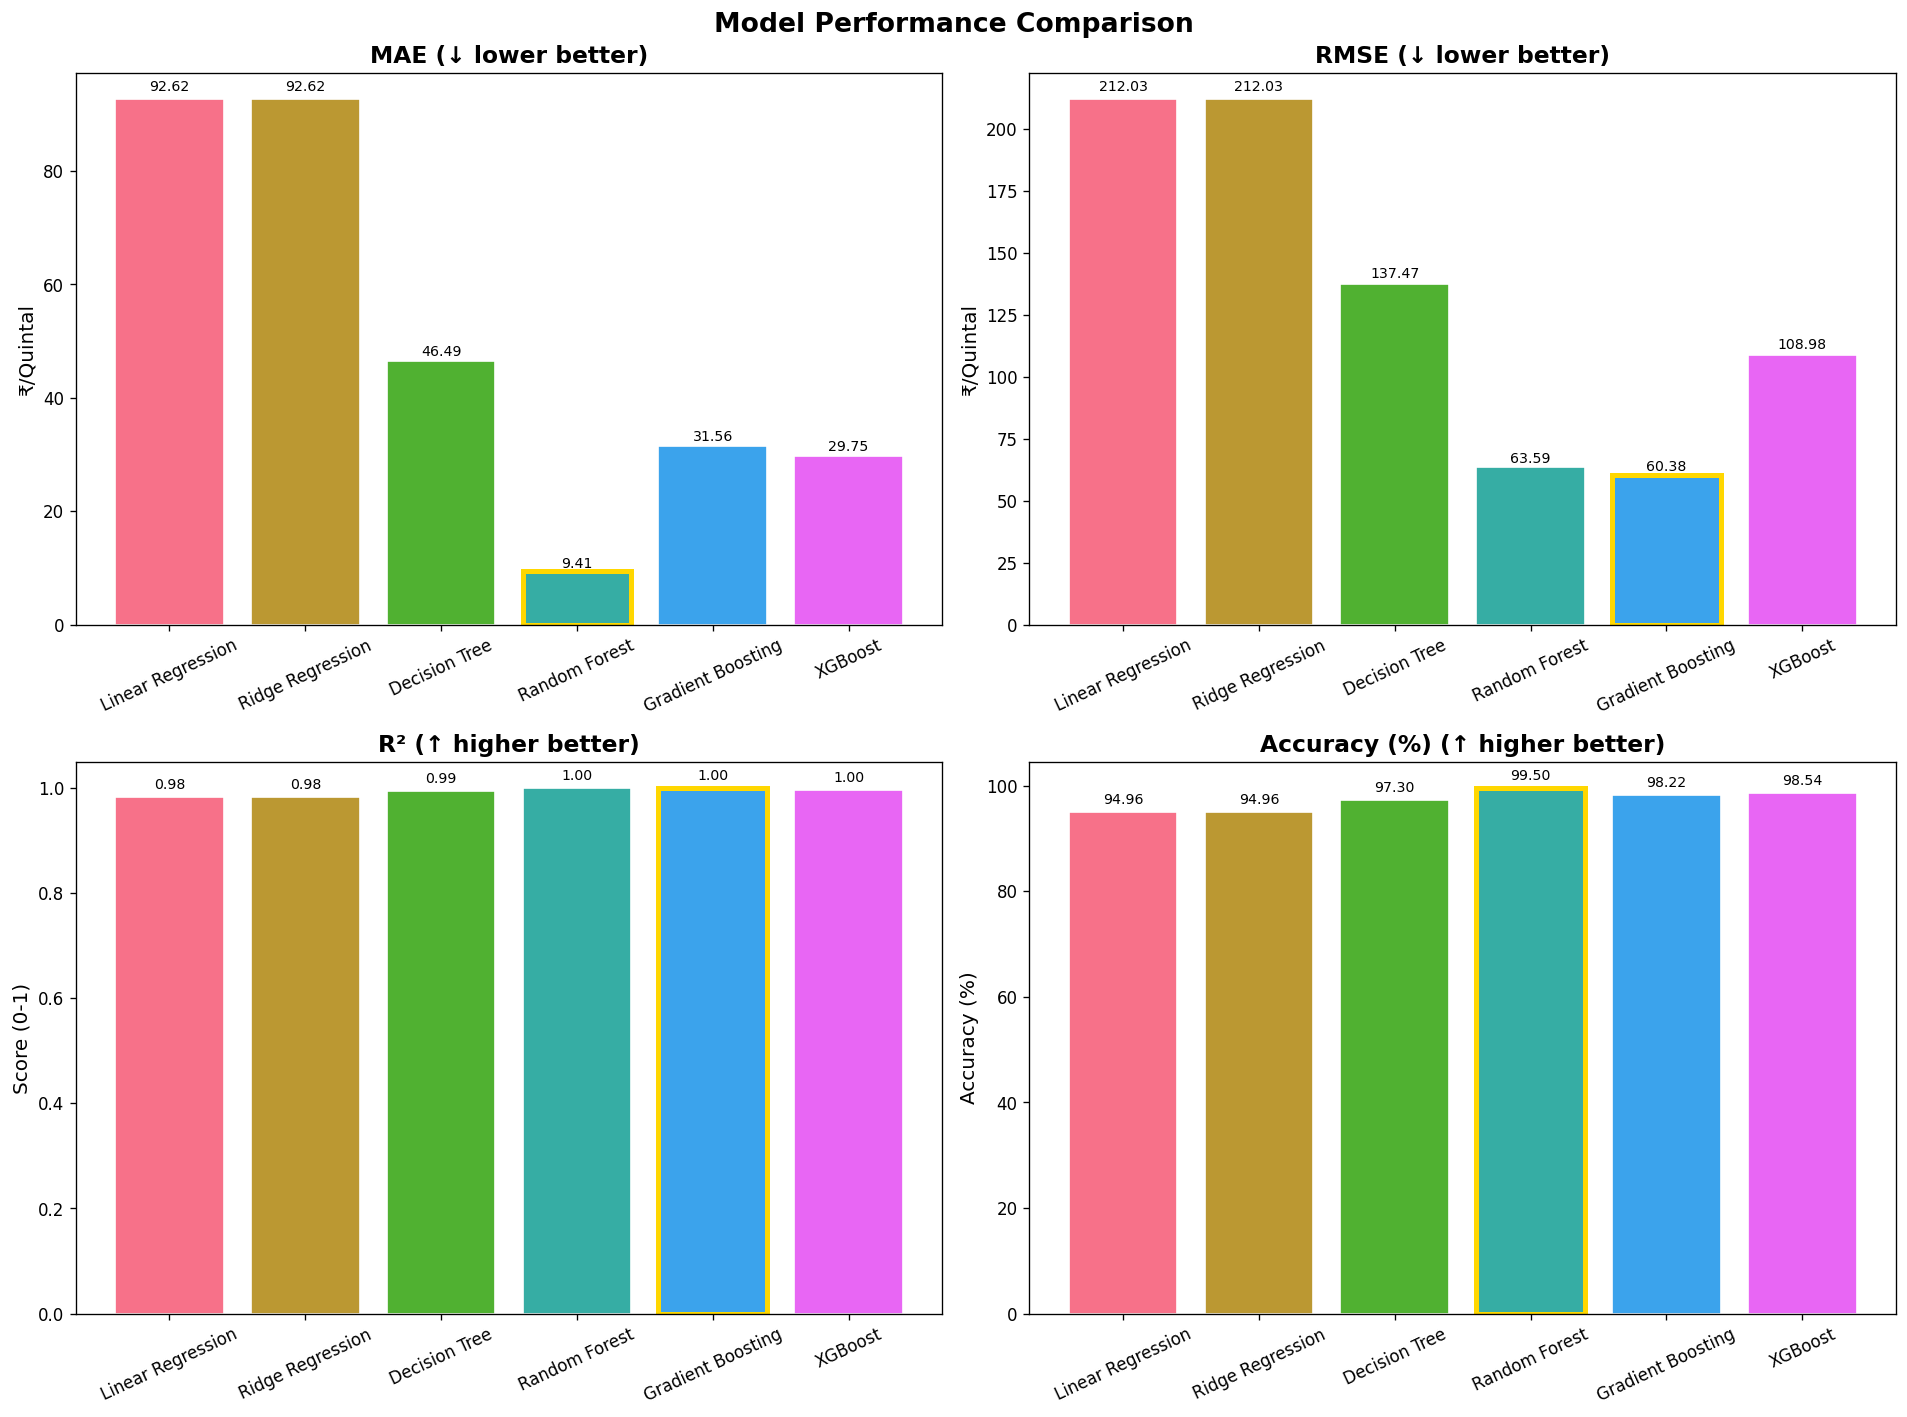

In [22]:
# ── 6.2 Metric Comparison Bar Charts ──────────────────────────────────────────
metrics_raw = pd.DataFrame({
    name: {k: v for k, v in res.items() if k != 'Predictions'}
    for name, res in results.items()
}).T

model_names_short = [n.split(' ', 1)[1] for n in metrics_raw.index]  # strip emoji
colors = sns.color_palette('husl', len(metrics_raw))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, metric, ylabel, better in zip(
    axes.flatten(),
    ['MAE', 'RMSE', 'R²', 'Accuracy (%)'],
    ['₹/Quintal', '₹/Quintal', 'Score (0-1)', 'Accuracy (%)'],
    ['lower', 'lower', 'higher', 'higher']
):
    vals = metrics_raw[metric].values
    bars = ax.bar(model_names_short, vals, color=colors, edgecolor='white')

    # Highlight best
    best_idx = np.argmin(vals) if better == 'lower' else np.argmax(vals)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8.5)

    ax.set_title(f'{metric} (↓ lower better)' if better == 'lower' else f'{metric} (↑ higher better)',
                 fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_09_model_comparison.png', bbox_inches='tight')
plt.show()

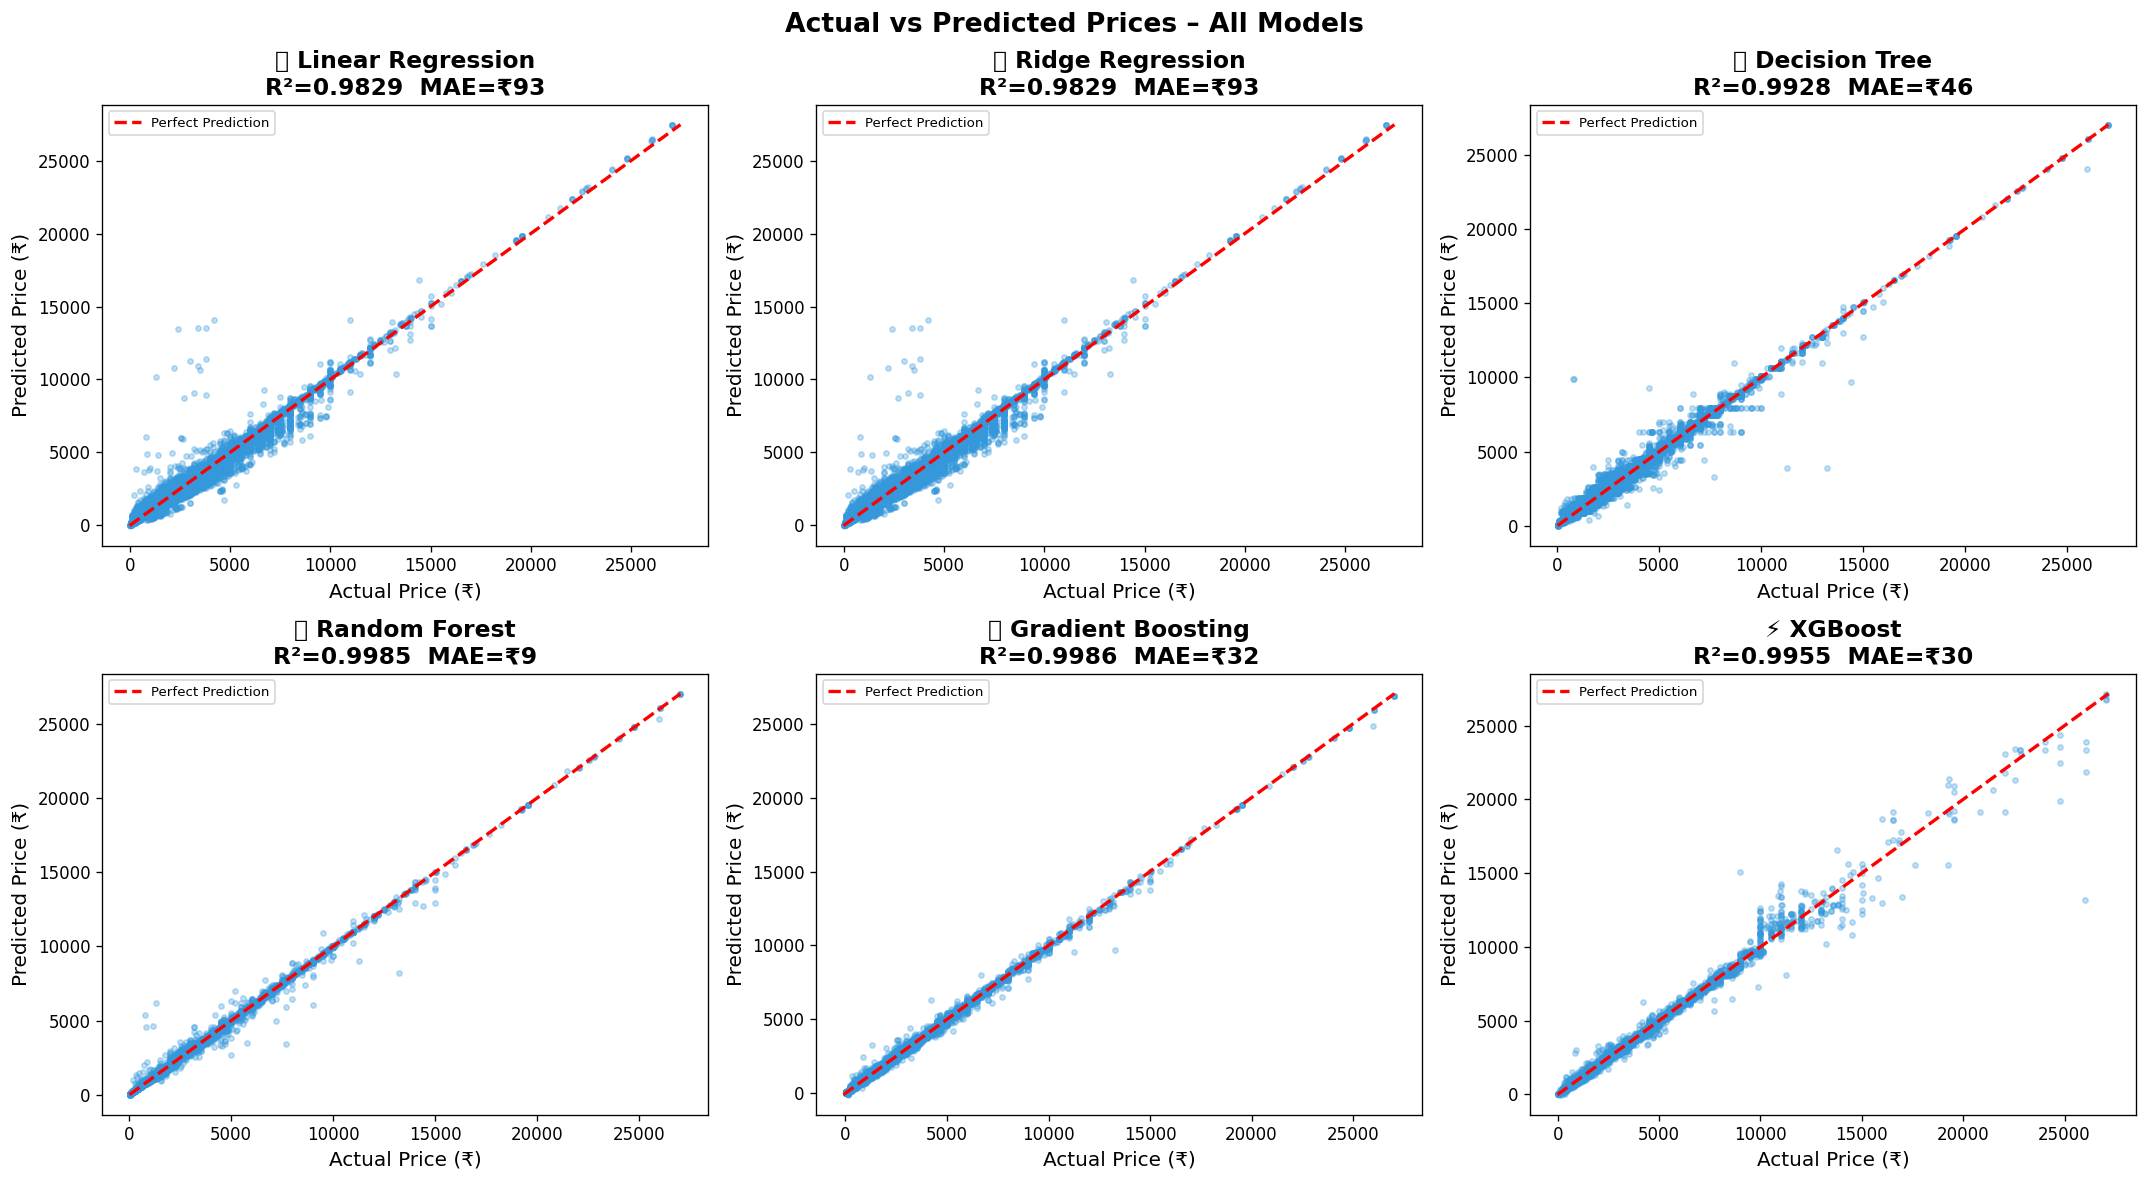

In [23]:
# ── 6.3 Actual vs Predicted Plots (All Models) ────────────────────────────────
n_models = len(results)
cols = 3
rows = (n_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    preds = res['Predictions']
    ax.scatter(y_test, preds, alpha=0.3, s=10, color='#3498db')

    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')

    ax.set_title(f'{name}\nR²={res["R²"]:.4f}  MAE=₹{res["MAE"]:,.0f}', fontweight='bold')
    ax.set_xlabel('Actual Price (₹)')
    ax.set_ylabel('Predicted Price (₹)')
    ax.legend(fontsize=8)

# Hide unused axes
for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle('Actual vs Predicted Prices – All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_10_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

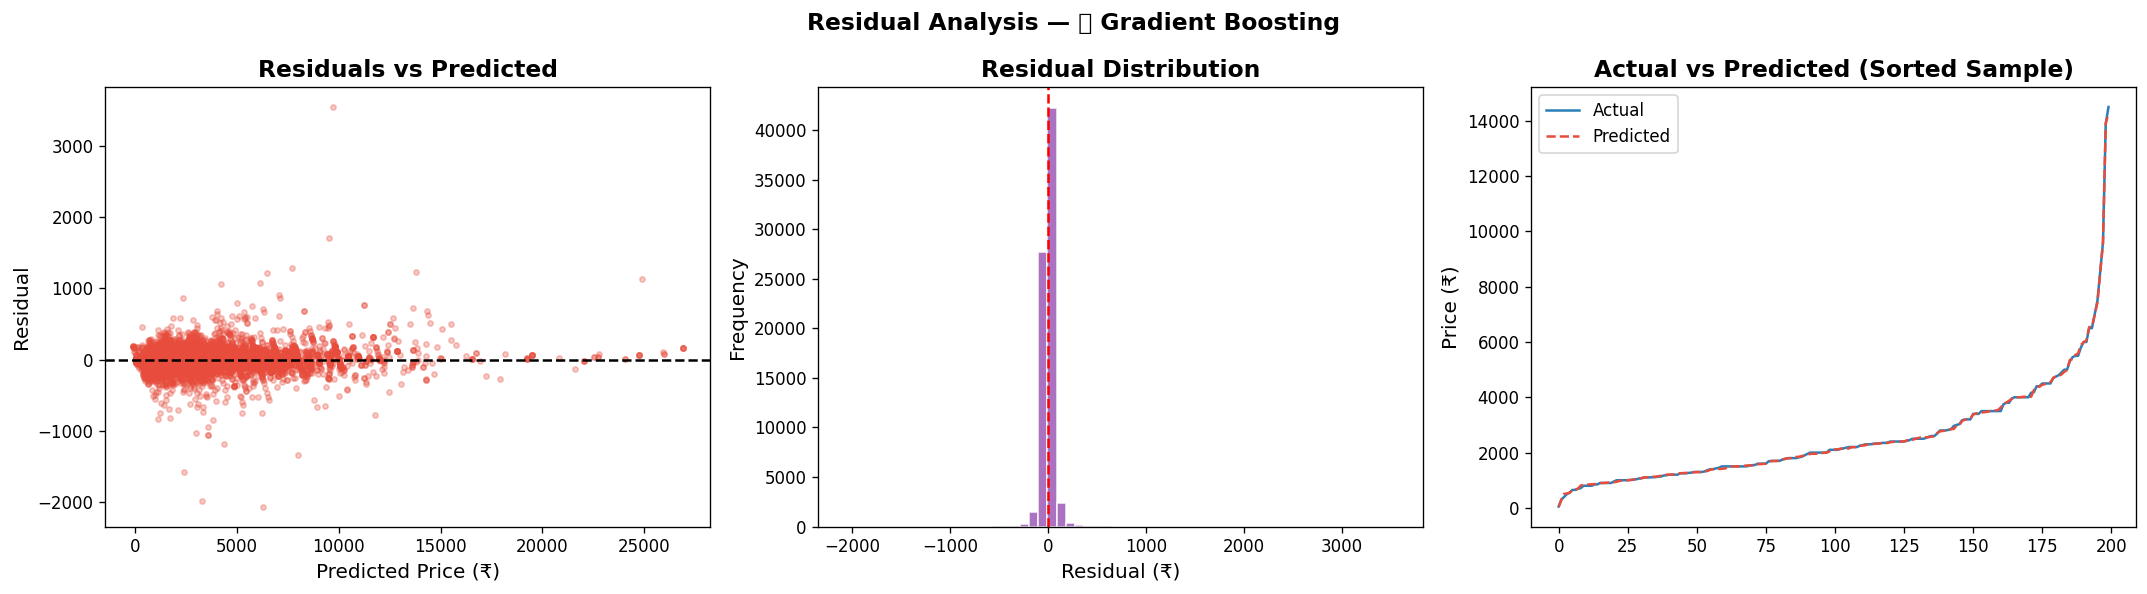


🏆 Best Model: 🚀 Gradient Boosting
   R²       : 0.9986
   MAE      : ₹31.56
   RMSE     : ₹60.38
   Accuracy : ≈98.22%


In [24]:
# ── 6.4 Residual Analysis (Best Model) ────────────────────────────────────────
metrics_raw_num = pd.DataFrame({
    name: {k: v for k, v in res.items() if k != 'Predictions'}
    for name, res in results.items()
}).T

best_model_name = metrics_raw_num['R²'].idxmax()
best_preds = results[best_model_name]['Predictions']
residuals  = y_test.values - best_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residuals vs Predicted
axes[0].scatter(best_preds, residuals, alpha=0.3, s=10, color='#e74c3c')
axes[0].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')
axes[0].set_xlabel('Predicted Price (₹)')
axes[0].set_ylabel('Residual')

# Residual Distribution
axes[1].hist(residuals, bins=60, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual (₹)')
axes[1].set_ylabel('Frequency')

# Q-Q style: Actual vs Predicted sample
sample_idx = np.random.choice(len(y_test), min(200, len(y_test)), replace=False)
axes[2].plot(range(len(sample_idx)), sorted(y_test.values[sample_idx]), label='Actual', color='#2980b9')
axes[2].plot(range(len(sample_idx)), sorted(best_preds[sample_idx]), label='Predicted', color='#e74c3c', linestyle='--')
axes[2].set_title('Actual vs Predicted (Sorted Sample)', fontweight='bold')
axes[2].set_ylabel('Price (₹)')
axes[2].legend()

plt.suptitle(f'Residual Analysis — {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_11_residual_analysis.png', bbox_inches='tight')
plt.show()

print(f'\n🏆 Best Model: {best_model_name}')
print(f'   R²       : {results[best_model_name]["R²"]:.4f}')
print(f'   MAE      : ₹{results[best_model_name]["MAE"]:,.2f}')
print(f'   RMSE     : ₹{results[best_model_name]["RMSE"]:,.2f}')
print(f'   Accuracy : ≈{results[best_model_name]["Accuracy (%)"]:.2f}%')

Running 5-Fold Cross-Validation...
  Linear Regression   : R² = 0.9839 ± 0.0009
  Decision Tree       : R² = 0.9938 ± 0.0006
  Random Forest       : R² = 0.9988 ± 0.0004


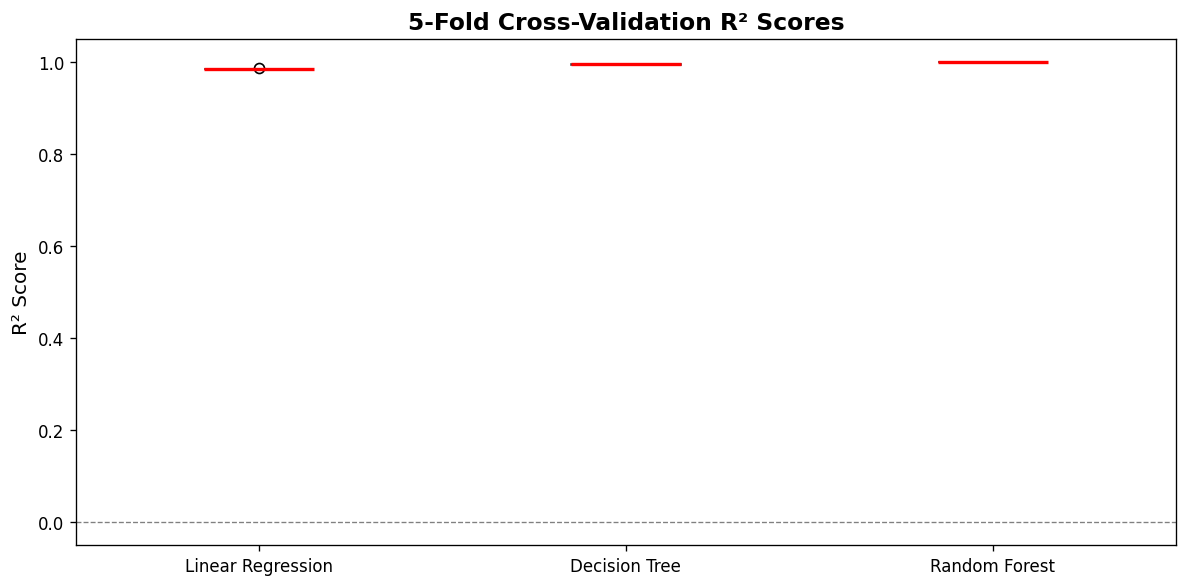

In [25]:
# ── 6.5 Cross-Validation (5-Fold) – Key Models ────────────────────────────────
cv_models = {
    'Linear Regression' : LinearRegression(),
    'Decision Tree'     : DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest'     : RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
}

cv_results = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print('Running 5-Fold Cross-Validation...')
for name, model in cv_models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f'  {name:20s}: R² = {scores.mean():.4f} ± {scores.std():.4f}')

# Boxplot of CV scores
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.7),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('5-Fold Cross-Validation R² Scores', fontsize=14, fontweight='bold')
ax.set_ylabel('R² Score')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('plot_12_cross_validation.png', bbox_inches='tight')
plt.show()

---
## 🌲 Step 7: Feature Importance (Random Forest)

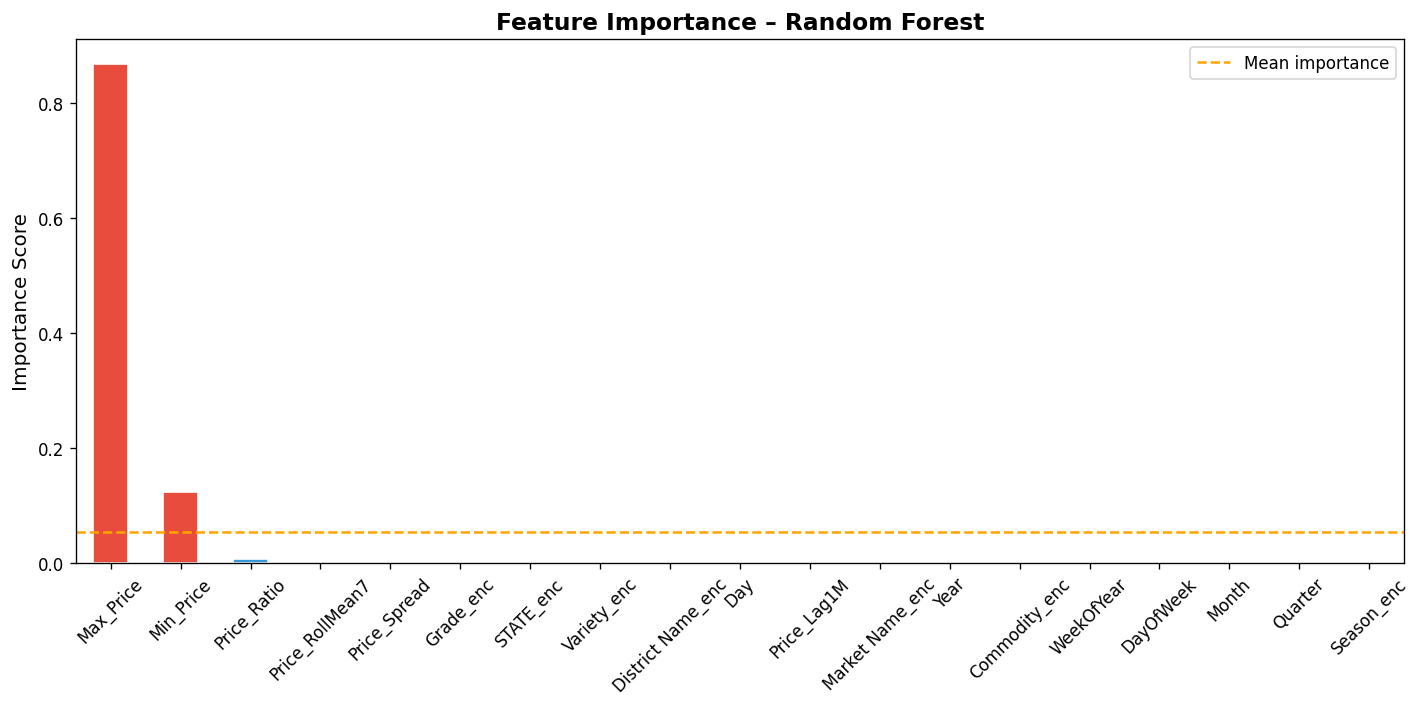


Top 10 Most Important Features:
   1. Max_Price                      : 0.8677
   2. Min_Price                      : 0.1224
   3. Price_Ratio                    : 0.0059
   4. Price_RollMean7                : 0.0010
   5. Price_Spread                   : 0.0008
   6. Grade_enc                      : 0.0005
   7. STATE_enc                      : 0.0005
   8. Variety_enc                    : 0.0004
   9. District Name_enc              : 0.0002
  10. Day                            : 0.0002


In [26]:
# ── 7.1 Feature Importance from Random Forest ─────────────────────────────────
rf_model = models['🌲 Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors_imp = ['#e74c3c' if imp > importances.mean() else '#3498db' for imp in importances.values]
importances.plot(kind='bar', ax=ax, color=colors_imp, edgecolor='white')
ax.axhline(importances.mean(), color='orange', linestyle='--', linewidth=1.5, label='Mean importance')
ax.set_title('Feature Importance – Random Forest', fontsize=14, fontweight='bold')
ax.set_ylabel('Importance Score')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('plot_13_feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 10 Most Important Features:')
for i, (feat, imp) in enumerate(importances.head(10).items(), 1):
    print(f'  {i:2d}. {feat:30s} : {imp:.4f}')

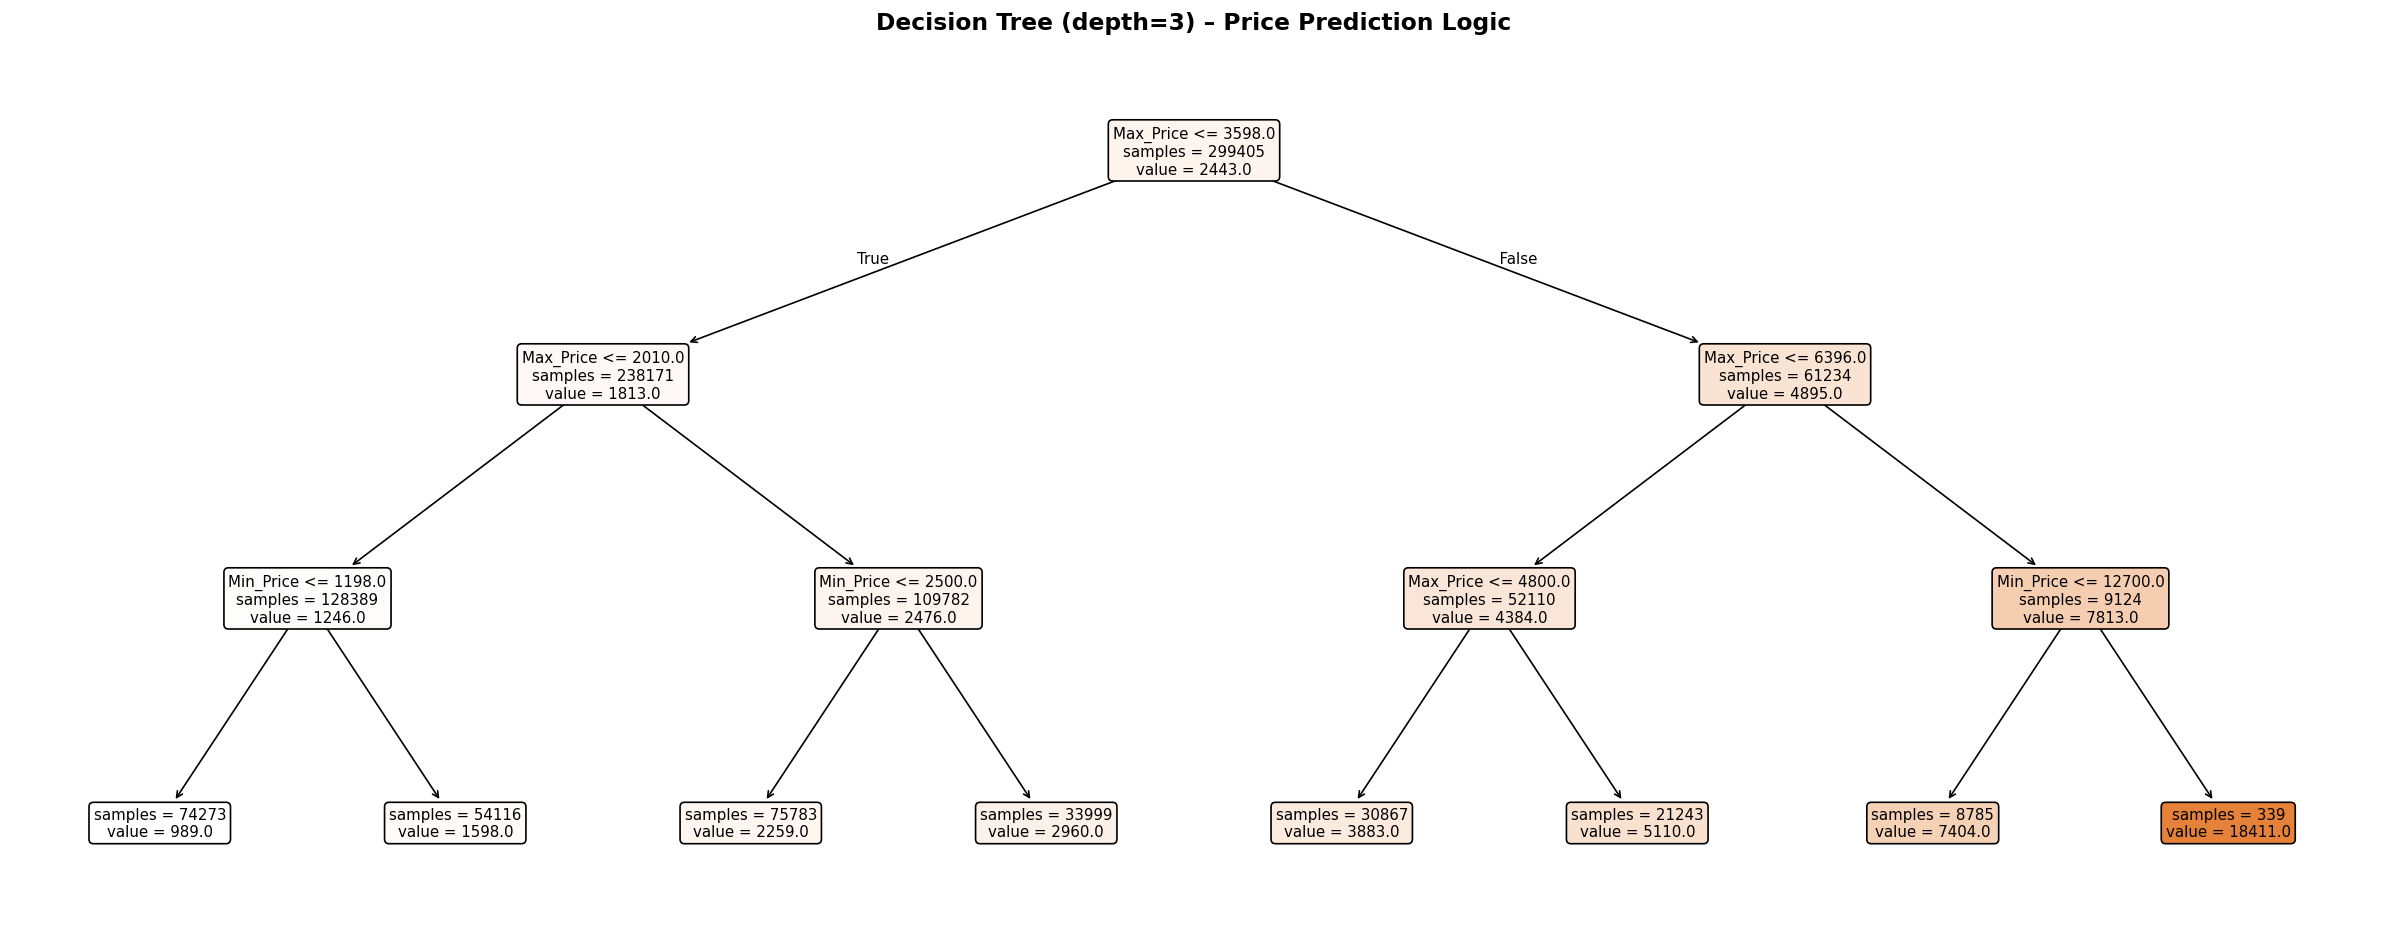

In [27]:
# ── 7.2 Decision Tree Visualisation (shallow, for interpretability) ───────────
dt_viz = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_viz.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_viz, feature_names=FEATURES, filled=True, rounded=True,
          max_depth=3, ax=ax, fontsize=9, impurity=False,
          precision=0)
ax.set_title('Decision Tree (depth=3) – Price Prediction Logic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_14_decision_tree.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 🔮 Step 8: Price Prediction — System Demo

In [28]:
# ── 8.1 Predict Function ───────────────────────────────────────────────────────
def predict_price(commodity=None, state=None, month=None, year=None,
                  model_name='🌲 Random Forest'):
    """
    Predict the modal price given commodity, state, and date info.
    All models in `results` can be selected.
    """
    inp = {}

    # Encode categorical inputs
    for col in cat_cols:
        val_map = {'State': state, 'Commodity': commodity}
        val_key = col  # may be 'State', 'Commodity', 'Market', etc.
        enc_col = col + '_enc'
        if enc_col in FEATURES:
            # Try to encode
            user_val = None
            for k, v in val_map.items():
                if k.lower() in col.lower() and v is not None:
                    user_val = v
            if user_val and user_val in label_encoders[col].classes_:
                inp[enc_col] = label_encoders[col].transform([user_val])[0]
            else:
                inp[enc_col] = label_encoders[col].transform([label_encoders[col].classes_[0]])[0]

    # Time features
    m = month or 6
    y_val = year or 2025
    for feat, val in [('Year', y_val), ('Month', m), ('Day', 15),
                      ('DayOfWeek', 2), ('Quarter', (m-1)//3 + 1), ('WeekOfYear', 24)]:
        if feat in FEATURES:
            inp[feat] = val

    # Price lag/roll features — use dataset median
    for feat in ['Price_Lag1M', 'Price_RollMean7', 'Price_Spread', 'Price_Ratio']:
        if feat in FEATURES:
            inp[feat] = df_model[feat].median()

    if MIN_COL and MIN_COL in FEATURES:
        inp[MIN_COL] = df_model[MIN_COL].median()
    if MAX_COL and MAX_COL in FEATURES:
        inp[MAX_COL] = df_model[MAX_COL].median()

    row = pd.DataFrame([inp])[FEATURES]
    model = models[model_name]

    if 'Linear' in model_name or 'Ridge' in model_name:
        row_sc = scaler.transform(row)
        pred = model.predict(row_sc)[0]
    else:
        pred = model.predict(row)[0]

    return max(0, round(pred, 2))


# ── Demo Predictions ───────────────────────────────────────────────────────────
# Replace these with any commodity/state from your dataset
test_cases = [
    {'commodity': 'Tomato',   'state': 'Karnataka',    'month': 6,  'year': 2025},
    {'commodity': 'Onion',    'state': 'Maharashtra',  'month': 1,  'year': 2025},
    {'commodity': 'Wheat',    'state': 'Punjab',       'month': 4,  'year': 2025},
    {'commodity': 'Potato',   'state': 'Uttar Pradesh','month': 10, 'year': 2025},
    {'commodity': 'Rice',     'state': 'Andhra Pradesh','month': 9, 'year': 2025},
]

print('='*65)
print('  PREDICTED MODAL PRICES (₹/Quintal)')
print('='*65)
print(f'{"Commodity":<12} {"State":<18} {"Month":>6} {"Year":>5}  {"Predicted Price":>15}')
print('-'*65)

for tc in test_cases:
    price = predict_price(**tc)
    print(f'{tc["commodity"]:<12} {tc["state"]:<18} {tc["month"]:>6} {tc["year"]:>5}  ₹{price:>13,.2f}')

print('='*65)

  PREDICTED MODAL PRICES (₹/Quintal)
Commodity    State               Month  Year  Predicted Price
-----------------------------------------------------------------
Tomato       Karnataka               6  2025  ₹     2,135.87
Onion        Maharashtra             1  2025  ₹     2,135.87
Wheat        Punjab                  4  2025  ₹     2,135.87
Potato       Uttar Pradesh          10  2025  ₹     2,135.87
Rice         Andhra Pradesh          9  2025  ₹     2,135.87


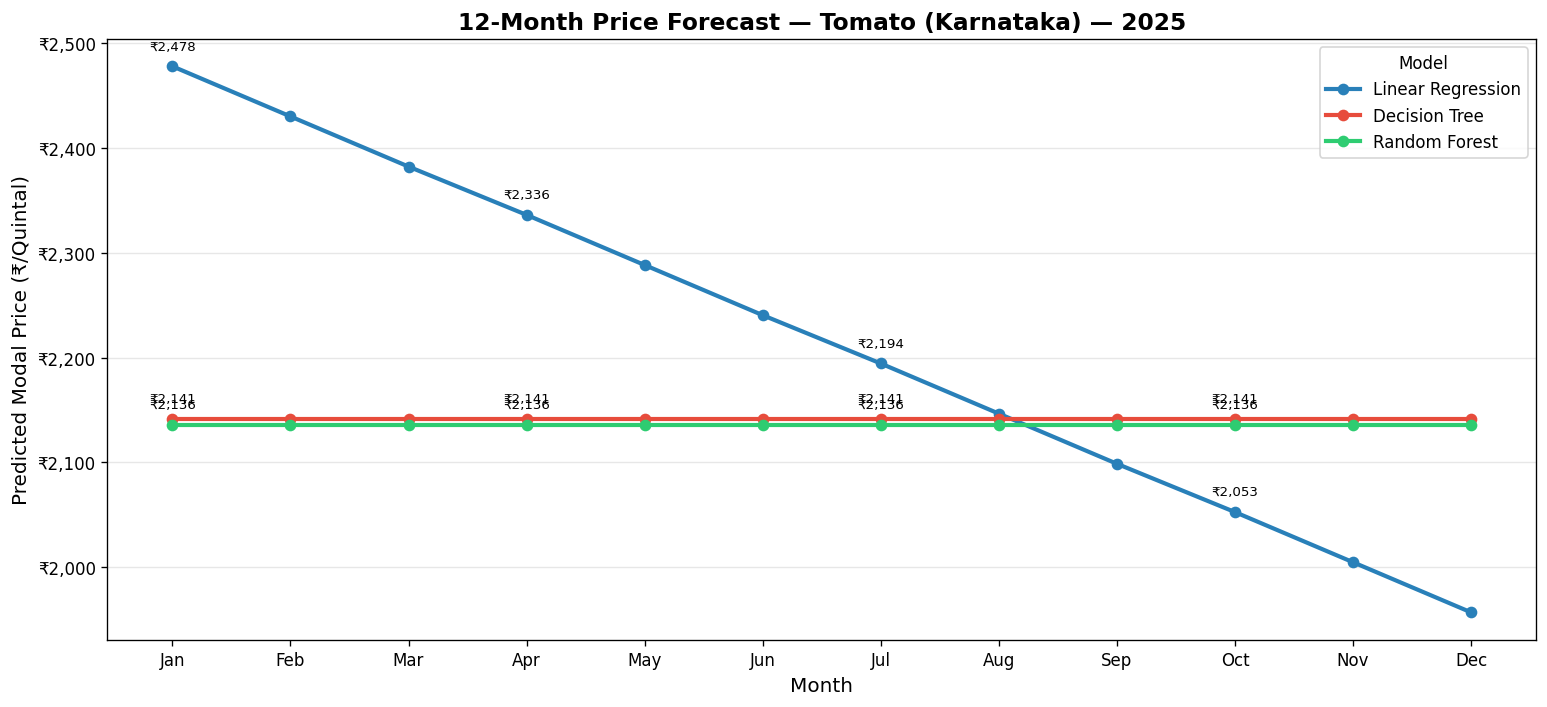


📈 Forecast generated for Tomato in Karnataka


In [29]:
# ── 8.2 Multi-month Forecast Chart ────────────────────────────────────────────
# Forecast prices for a selected commodity across all months
FORECAST_COMMODITY = 'Tomato'   # ← change to any commodity in your dataset
FORECAST_STATE     = 'Karnataka' # ← change to any state in your dataset

months = list(range(1, 13))
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

forecast_by_model = {}
for m_name in ['📐 Linear Regression', '🌳 Decision Tree', '🌲 Random Forest']:
    preds_month = [predict_price(commodity=FORECAST_COMMODITY,
                                 state=FORECAST_STATE,
                                 month=mo, year=2025,
                                 model_name=m_name) for mo in months]
    forecast_by_model[m_name.split(' ',1)[1]] = preds_month

fig, ax = plt.subplots(figsize=(13, 6))
colors_fc = ['#2980b9', '#e74c3c', '#2ecc71']

for (m_name, preds), color in zip(forecast_by_model.items(), colors_fc):
    ax.plot(month_names, preds, marker='o', linewidth=2.5, label=m_name, color=color)
    for i, val in enumerate(preds):
        if i % 3 == 0:  # annotate every 3rd point
            ax.annotate(f'₹{val:,.0f}', (month_names[i], val),
                        textcoords='offset points', xytext=(0, 10),
                        fontsize=8, ha='center')

ax.set_title(f'12-Month Price Forecast — {FORECAST_COMMODITY} ({FORECAST_STATE}) — 2025',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Predicted Modal Price (₹/Quintal)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.legend(title='Model')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_15_forecast.png', bbox_inches='tight')
plt.show()

print(f'\n📈 Forecast generated for {FORECAST_COMMODITY} in {FORECAST_STATE}')

In [30]:
# ── 8.3 Farmer Decision Support Output ────────────────────────────────────────
def farmer_advice(commodity, state, month, year, threshold_pct=10):
    """
    Give sell/hold recommendation based on predicted price vs historical mean.
    """
    predicted = predict_price(commodity, state, month, year)

    if COMMODITY_COL and commodity in df[COMMODITY_COL].values:
        hist_mean = df[df[COMMODITY_COL] == commodity][MODAL_COL].mean()
    else:
        hist_mean = df[MODAL_COL].mean()

    change_pct = ((predicted - hist_mean) / hist_mean) * 100

    print('─' * 60)
    print(f'  🌾 FARMER DECISION SUPPORT SYSTEM')
    print('─' * 60)
    print(f'  Commodity        : {commodity}')
    print(f'  State            : {state}')
    print(f'  Forecast Month   : {month}/{year}')
    print(f'  Predicted Price  : ₹{predicted:,.2f}/Quintal')
    print(f'  Historical Mean  : ₹{hist_mean:,.2f}/Quintal')
    print(f'  Expected Change  : {change_pct:+.2f}%')
    print()

    if change_pct >= threshold_pct:
        advice = '✅ SELL — Price is predicted to be ABOVE average. Good time to sell!'
    elif change_pct <= -threshold_pct:
        advice = '⏳ HOLD — Price is predicted to be BELOW average. Consider waiting.'
    else:
        advice = '⚖️  NEUTRAL — Price near average. Monitor market closely.'

    print(f'  Recommendation   : {advice}')
    print('─' * 60)


# Demo
farmer_advice('Tomato', 'Karnataka', 6, 2025)
farmer_advice('Onion',  'Maharashtra', 2, 2025)
farmer_advice('Wheat',  'Punjab', 4, 2025)

────────────────────────────────────────────────────────────
  🌾 FARMER DECISION SUPPORT SYSTEM
────────────────────────────────────────────────────────────
  Commodity        : Tomato
  State            : Karnataka
  Forecast Month   : 6/2025
  Predicted Price  : ₹2,135.87/Quintal
  Historical Mean  : ₹4,355.46/Quintal
  Expected Change  : -50.96%

  Recommendation   : ⏳ HOLD — Price is predicted to be BELOW average. Consider waiting.
────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────
  🌾 FARMER DECISION SUPPORT SYSTEM
────────────────────────────────────────────────────────────
  Commodity        : Onion
  State            : Maharashtra
  Forecast Month   : 2/2025
  Predicted Price  : ₹2,135.87/Quintal
  Historical Mean  : ₹2,741.56/Quintal
  Expected Change  : -22.09%

  Recommendation   : ⏳ HOLD — Price is predicted to be BELOW average. Consider waiting.
──────────────────────────────────────────────────────────

---
## 📋 Step 9: Final Summary Report

In [31]:
# ── 9.1 Final Summary ─────────────────────────────────────────────────────────
print('=' * 70)
print('  FINAL PROJECT SUMMARY REPORT')
print('  Market Price Prediction using Machine Learning')
print('  CSE23602 | Global Academy of Technology, Bengaluru')
print('=' * 70)

print(f'\n📦 Dataset:')
print(f'   Total records processed : {len(df):,}')
print(f'   Features engineered     : {len(FEATURES)}')
print(f'   Training samples         : {len(X_train):,}')
print(f'   Testing samples          : {len(X_test):,}')

print(f'\n🤖 Models Evaluated:')
for name in results:
    print(f'   {name}')

print(f'\n🏆 Best Performing Model: {best_model_name}')
best = results[best_model_name]
print(f'   R² Score        : {best["R²"]:.4f}  (1.0 = perfect fit)')
print(f'   MAE             : ₹{best["MAE"]:,.2f}/Quintal')
print(f'   RMSE            : ₹{best["RMSE"]:,.2f}/Quintal')
print(f'   MAPE            : {best["MAPE (%)"]:.2f}%')
print(f'   Accuracy (est.) : {best["Accuracy (%)"]:.2f}%')

print('\n📊 Key Outputs Generated:')
plots = [
    'Missing values & data quality',
    'Price distribution analysis',
    'Commodity & state coverage',
    'Avg price by commodity',
    'Monthly price trend (2023–2025)',
    'Per-commodity price trends',
    'Feature correlation heatmap',
    'Train/test split visualization',
    'Model comparison bar charts',
    'Actual vs predicted scatter plots',
    'Residual analysis (best model)',
    '5-fold cross-validation scores',
    'Feature importance (Random Forest)',
    'Decision tree visualization',
    '12-month price forecast',
]
for i, p in enumerate(plots, 1):
    print(f'   {i:2d}. {p}')

print('\n✅ Objectives Achieved:')
for obj in [
    'Collected and merged multiple agricultural mandi datasets',
    'Preprocessed data: removed duplicates, handled outliers, encoded categoricals',
    'Engineered time, lag, and price-spread features',
    'Trained & compared Linear Regression, Decision Tree, Random Forest, GB, XGBoost',
    'Evaluated using MAE, RMSE, MAPE, R², and 5-fold cross-validation',
    'Built a farmer decision-support system with sell/hold recommendations',
    'Visualised 12-month commodity price forecasts',
]:
    print(f'   ✔ {obj}')

print('\n' + '=' * 70)

  FINAL PROJECT SUMMARY REPORT
  Market Price Prediction using Machine Learning
  CSE23602 | Global Academy of Technology, Bengaluru

📦 Dataset:
   Total records processed : 400,419
   Features engineered     : 19
   Training samples         : 299,405
   Testing samples          : 74,852

🤖 Models Evaluated:
   📐 Linear Regression
   🔱 Ridge Regression
   🌳 Decision Tree
   🌲 Random Forest
   🚀 Gradient Boosting
   ⚡ XGBoost

🏆 Best Performing Model: 🚀 Gradient Boosting
   R² Score        : 0.9986  (1.0 = perfect fit)
   MAE             : ₹31.56/Quintal
   RMSE            : ₹60.38/Quintal
   MAPE            : 1.78%
   Accuracy (est.) : 98.22%

📊 Key Outputs Generated:
    1. Missing values & data quality
    2. Price distribution analysis
    3. Commodity & state coverage
    4. Avg price by commodity
    5. Monthly price trend (2023–2025)
    6. Per-commodity price trends
    7. Feature correlation heatmap
    8. Train/test split visualization
    9. Model comparison bar charts
   10.

In [32]:
# ── 9.2 Save Best Model ────────────────────────────────────────────────────────
import pickle, os

os.makedirs('saved_model', exist_ok=True)

best_model_obj = models[best_model_name]

with open('saved_model/best_model.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)

with open('saved_model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('saved_model/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

with open('saved_model/feature_list.pkl', 'wb') as f:
    pickle.dump(FEATURES, f)

print(f'✅ Best model saved: saved_model/best_model.pkl')
print(f'   Model type : {type(best_model_obj).__name__}')
print(f'   Scaler     : saved_model/scaler.pkl')
print(f'   Encoders   : saved_model/label_encoders.pkl')
print(f'   Features   : saved_model/feature_list.pkl')

print('\n🎓 Project Complete! All outputs saved.')

✅ Best model saved: saved_model/best_model.pkl
   Model type : GradientBoostingRegressor
   Scaler     : saved_model/scaler.pkl
   Encoders   : saved_model/label_encoders.pkl
   Features   : saved_model/feature_list.pkl

🎓 Project Complete! All outputs saved.
